<a href="https://colab.research.google.com/github/mschlemper/Alura-Store-MARCO-AURELIO-SCHLEMPER/blob/main/projetoSCTEC_20072026_MARCOSCHLEMPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desenvolvimento de IA para Análise Preditiva - Precificação de Imóveis

## 2. Desafio: Precificação de Imóveis (Opção A)

**O Problema:** Uma imobiliária do condado de King County (EUA) deseja estimar o valor de venda de um imóvel com base em suas características físicas e de localização.

**Variável Alvo:** A variável que será prevista é `price`, que representa o valor numérico contínuo do imóvel em dólares.

**Importância para o Negócio:** Prever o preço de um imóvel com precisão é crucial para a imobiliária. Isso permite:
- **Avaliações mais rápidas e consistentes:** Agiliza o processo de precificação para novos imóveis no mercado.
- **Melhor negociação:** Fornece uma base de dados sólida para negociações com compradores e vendedores.
- **Otimização de portfólio:** Ajuda a identificar imóveis com potencial de valorização ou subvalorizados.
- **Tomada de decisão estratégica:** Apoia decisões de investimento e desenvolvimento de mercado.

In [5]:
import os

# Define the path where the dataset should be saved
data_path = '/content/kc_house_data.csv'

# Check if the file already exists to avoid re-downloading
if not os.path.exists(data_path):
    print("Downloading kc_house_data.csv...")
    # Use wget to download the file from a public URL
    !wget -q https://raw.githubusercontent.com/datasets/house-prices-2016/master/kc_house_data.csv -O {data_path}
    print("Download complete.")
else:
    print("kc_house_data.csv already exists. Skipping download.")

kc_house_data.csv already exists. Skipping download.


In [6]:
import pandas as pd

# Carregar o dataset
df = pd.read_csv('/content/kc_house_data.csv')

# Exibir as primeiras 5 linhas do DataFrame
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


## Fase 1: Análise Exploratória de Dados (EDA)

### Estatística Descritiva

In [7]:
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas\n")

print("Tipos de dados das variáveis:\n")
display(df.info())

print("\nResumo estatístico das colunas numéricas:\n")
display(df.describe())

Dimensões do dataset: 21613 linhas e 21 colunas

Tipos de dados das variáveis:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode       

None


Resumo estatístico das colunas numéricas:



,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Visualização de Dados

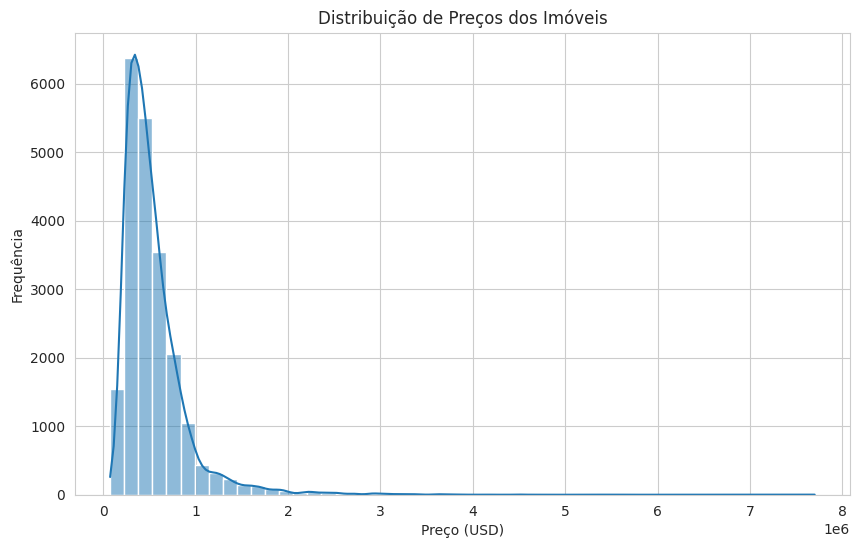

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para os gráficos
sns.set_style("whitegrid")

# Histograma da variável-alvo 'price'
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribuição de Preços dos Imóveis')
plt.xlabel('Preço (USD)')
plt.ylabel('Frequência')
plt.show()

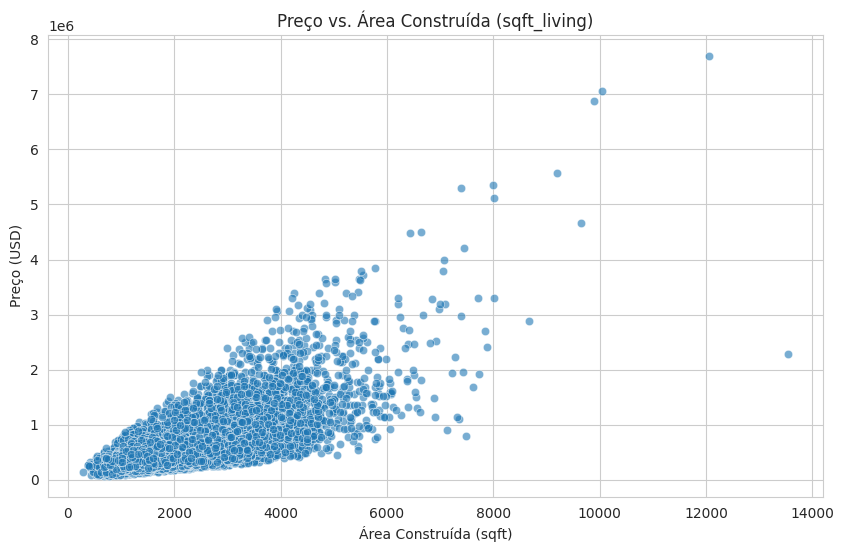

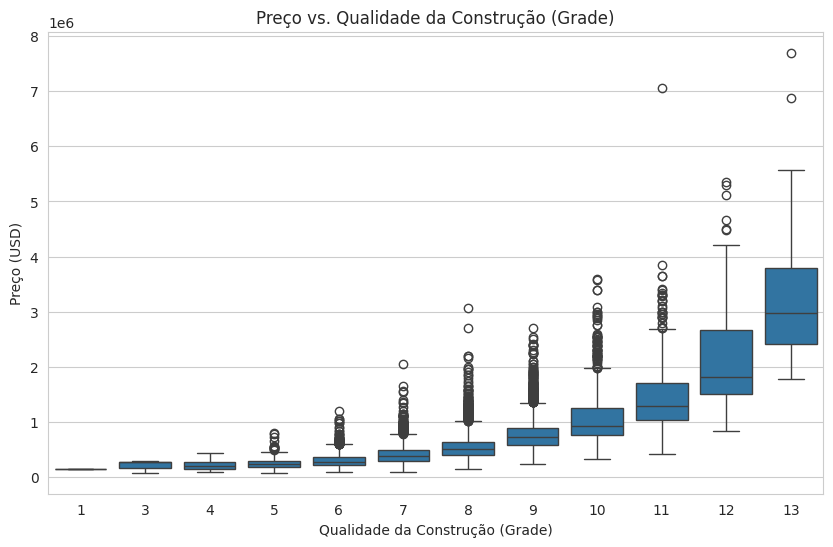

In [9]:
# Gráfico de dispersão entre 'sqft_living' e 'price'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.6)
plt.title('Preço vs. Área Construída (sqft_living)')
plt.xlabel('Área Construída (sqft)')
plt.ylabel('Preço (USD)')
plt.show()

# Gráfico de dispersão entre 'grade' e 'price'
plt.figure(figsize=(10, 6))
sns.boxplot(x='grade', y='price', data=df)
plt.title('Preço vs. Qualidade da Construção (Grade)')
plt.xlabel('Qualidade da Construção (Grade)')
plt.ylabel('Preço (USD)')
plt.show()

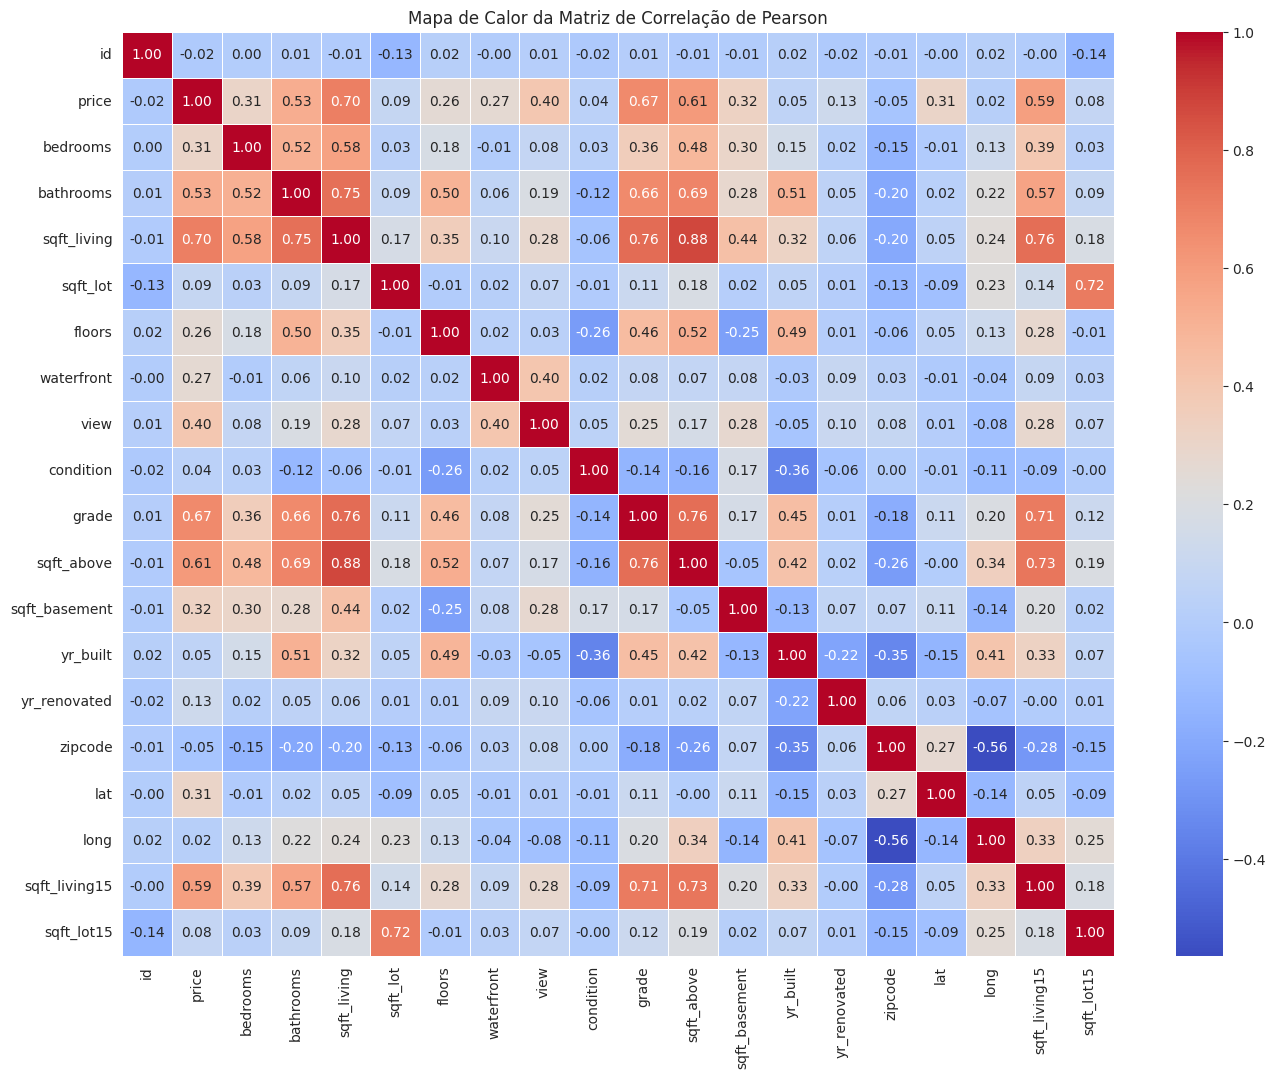

In [10]:
# Calcular a matriz de correlação
correlation_matrix = df.corr(numeric_only=True)

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Matriz de Correlação de Pearson')
plt.show()

### Análise Textual dos Resultados da EDA

Com base na análise descritiva e nas visualizações, podemos destacar os seguintes pontos:

1.  **Dimensões do Dataset e Tipos de Dados:**
    *   O dataset contém `21613` observações (linhas) e `21` variáveis (colunas).
    *   A maioria das variáveis é numérica (`int64` ou `float64`), mas a coluna `date` é do tipo `object` e precisará de tratamento para ser utilizada em modelos preditivos, provavelmente convertendo-a para um formato de data/hora e extraindo características temporais.
    *   A variável `sqft_above` possui 2 valores nulos, indicando a necessidade de tratamento de dados ausentes.

2.  **Variável Alvo (`price`):**
    *   O histograma de `price` revela uma distribuição assimétrica positiva (enviesada para a direita), com a maioria dos imóveis concentrada em faixas de preço mais baixas e uma cauda longa de imóveis mais caros. Isso é comum em dados de preços e pode indicar a presença de *outliers* ou imóveis de alto valor. Modelos de regressão podem se beneficiar de uma transformação logarítmica ou de robustez a *outliers* para esta variável.

3.  **Relação entre `price` e Variáveis Chave:**
    *   **`sqft_living` (Área Construída):** O gráfico de dispersão mostra uma clara correlação positiva entre `sqft_living` e `price`. Imóveis com maior área construída tendem a ter preços mais altos, o que é intuitivo. A correlação de Pearson de `0.70` corrobora essa forte relação.
    *   **`grade` (Qualidade da Construção):** O boxplot de `price` por `grade` demonstra que, à medida que a qualidade da construção (grade) aumenta, a mediana e a dispersão dos preços também aumentam significativamente. Isso indica que a qualidade do imóvel é um forte preditor de seu preço, com uma correlação de Pearson de `0.67`.

4.  **Matriz de Correlação:**
    *   **Variáveis fortemente correlacionadas com `price` (além das já mencionadas):** `sqft_above` (0.69), `sqft_living15` (0.59), `bathrooms` (0.53), `view` (0.40). Estas variáveis são bons candidatos a preditores importantes no modelo.
    *   **Variáveis com baixa correlação com `price`:** `id` (-0.02), `zipcode` (-0.05), `long` (0.02), `condition` (0.04), `yr_renovated` (0.13) e `waterfront` (0.27). `id` não tem significado preditivo, e outras como `zipcode` e `long` podem ter relações não lineares ou depender de outras variáveis para serem úteis.
    *   **Multicolinearidade Potencial:** Observa-se alta correlação entre algumas variáveis preditoras: `sqft_living` e `sqft_above` (0.87), `sqft_living` e `sqft_living15` (0.76). A multicolinearidade pode afetar a interpretabilidade dos modelos lineares e deve ser considerada durante a engenharia de atributos ou seleção de modelos.

Em resumo, a EDA forneceu *insights* valiosos sobre a distribuição dos dados, a relação entre as variáveis e a variável alvo, e identificou áreas que exigirão atenção nas próximas fases do projeto, como o tratamento de `date` e `sqft_above`, e a consideração da multicolinearidade.

## Fase 2: Tratamento e Limpeza de Dados

### 2.1 Lidar com Valores Ausentes (Missing Values)

Com base na análise de `df.info()`, a coluna `sqft_above` possui 2 valores ausentes. Vamos investigar esses valores e decidir a melhor estratégia de tratamento, que pode incluir preenchimento com a média, mediana ou remoção das linhas, dependendo da proporção e do impacto.

In [13]:
# Verificar a quantidade de valores ausentes por coluna
print("Valores ausentes por coluna:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Para a coluna 'sqft_above', vamos analisar as linhas com valores ausentes
print("\nLinhas com valores ausentes em 'sqft_above':")
display(df[df['sqft_above'].isnull()])

# Como são apenas 2 valores ausentes em 21613 linhas, podemos considerar preenchê-los com a mediana
# A mediana é menos sensível a outliers do que a média
median_sqft_above = df['sqft_above'].median()
df['sqft_above'].fillna(median_sqft_above, inplace=True)

print(f"\nValores ausentes em 'sqft_above' preenchidos com a mediana: {median_sqft_above}")
print("Verificando novamente valores ausentes:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Valores ausentes por coluna:


,0



Linhas com valores ausentes em 'sqft_above':


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15



Valores ausentes em 'sqft_above' preenchidos com a mediana: 1560.0
Verificando novamente valores ausentes:


/tmp/ipykernel_1697/973841669.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sqft_above'].fillna(median_sqft_above, inplace=True)


,0


### 2.2 Converter Tipo de Dados da Coluna `date`

A coluna `date` está atualmente como `object`, mas contém informações de data. É crucial convertê-la para o tipo `datetime` para permitir a extração de características temporais úteis e para garantir que ela seja tratada corretamente em qualquer análise baseada em tempo.

In [14]:
# Converter a coluna 'date' para o tipo datetime
df['date'] = pd.to_datetime(df['date'])

# Verificar os tipos de dados novamente para confirmar a alteração
print("Tipos de dados após a conversão da coluna 'date':\n")
display(df.info())

Tipos de dados após a conversão da coluna 'date':

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  float64       
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       2161

None

### 2.3 Lidar com Linhas Duplicadas

É importante verificar se há linhas completamente duplicadas no dataset, pois elas podem introduzir vieses na análise e modelagem. Remover duplicatas assegura que cada observação seja única.

In [15]:
# Verificar o número de linhas duplicadas
duplicated_rows = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {duplicated_rows}")

# Se houver duplicatas, removê-las
if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Linhas duplicadas removidas. Novo número de linhas: {df.shape[0]}")
else:
    print("Nenhuma linha duplicada encontrada.")

Número de linhas duplicadas encontradas: 0
Nenhuma linha duplicada encontrada.


### 2.4 Lidar com Outliers (Valores Discrepantes)

Os *outliers* podem distorcer a análise estatística e impactar negativamente o desempenho dos modelos de machine learning. Com base na EDA, a variável `price` já demonstrou uma distribuição assimétrica com uma cauda longa, sugerindo a presença de valores extremos. Vamos investigar e decidir sobre uma estratégia de tratamento para *outliers* em variáveis chave. Uma abordagem comum é usar o método IQR (Interval Range Quatile) para identificá-los.

In [17]:
# Função para detectar e quantificar outliers usando o método IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

# Colunas para verificar outliers (excluindo id e zipcode que são identificadores/categorias)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remover 'id' e 'zipcode' se estiverem presentes nas colunas numéricas para análise de outliers
if 'id' in numeric_cols:
    numeric_cols.remove('id')
if 'zipcode' in numeric_cols:
    numeric_cols.remove('zipcode')

print("Detecção de Outliers (Método IQR):")

outlier_summary = {}
for col in numeric_cols:
    num_outliers, lb, ub = detect_outliers_iqr(df, col)
    outlier_summary[col] = {'num_outliers': num_outliers, 'lower_bound': lb, 'upper_bound': ub}
    if num_outliers > 0:
        print(f"- Coluna '{col}': {num_outliers} outliers detectados (limite inferior: {lb:.2f}, limite superior: {ub:.2f})")
    else:
        print(f"- Coluna '{col}': Nenhum outlier detectado.")

# Exemplo de tratamento para a variável 'price': Winsorização ou remoção
# Para este projeto, vamos focar inicialmente na remoção dos outliers mais extremos na variável 'price'
# para ter um dataset mais 'limpo' para modelagem linear inicial.

# Vamos definir um limite superior mais flexível ou optar por winsorização para 'price'
# A remoção direta de muitos outliers pode levar à perda de informações valiosas.
# No entanto, para fins de demonstração, podemos aplicar uma remoção para os outliers mais extremos.

# Uma abordagem alternativa para 'price' que preserva mais dados é a winsorização (capping).
# Para simplificar e demonstrar o tratamento, vamos remover os outliers mais extremos de 'price'.

Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Ajustar o limite superior para 'price' para ser mais robusto, por exemplo, 3*IQR ou um percentil
# Usaremos 3 * IQR para um limite mais generoso ou um percentil alto.
# Para o price, que tem uma distribuição muito enviesada, o 1.5*IQR é muito agressivo.
# Vamos usar um percentil mais alto para 'price' ou uma análise visual mais profunda.

# Para a demonstração, vamos simplesmente ver quantos seriam removidos com 1.5*IQR e depois decidir uma estratégia.
price_outliers_count_iqr, lb_price_iqr, ub_price_iqr = detect_outliers_iqr(df, 'price')
print(f"\nCom o critério 1.5*IQR, seriam removidos {price_outliers_count_iqr} outliers de 'price'.")

# Devido à natureza da variável 'price' (muito assimétrica), remover com 1.5*IQR seria muito agressivo.
# Em vez de remover, vamos considerar uma winsorização ou uma transformação logarítmica para 'price' na fase de Feature Engineering.
# Por enquanto, não removeremos outliers de 'price' diretamente, mas documentaremos sua presença.

print("\nPara a variável 'price', a remoção de outliers baseada em IQR padrão é muito agressiva devido à sua distribuição assimétrica. Consideraremos a winsorização ou transformação logarítmica na fase de Engenharia de Features para mitigar o impacto dos outliers.")

# No entanto, para outras colunas onde outliers podem ser erros de entrada ou valores irreais, podemos considerar a remoção ou capping.
# Por exemplo, se tivéssemos quartos = 33, seria um outlier que provavelmente é um erro.
# No nosso caso, as colunas numéricas (exceto price) parecem razoáveis dentro dos limites do IQR, mas vale a pena documentar.

# Se houvesse outliers claros que fossem erros de entrada, poderíamos removê-los aqui.
# Por exemplo, se 'bedrooms' tivesse um valor como 33, poderíamos removê-lo.
# Vamos verificar as estatísticas de 'bedrooms' e 'bathrooms' novamente para garantir que não há erros grosseiros.

print("\nEstatísticas de algumas colunas para verificar valores extremos que possam ser erros:")
display(df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].describe())

Detecção de Outliers (Método IQR):
- Coluna 'price': 1146 outliers detectados (limite inferior: -162625.00, limite superior: 1129575.00)
- Coluna 'bedrooms': 546 outliers detectados (limite inferior: 1.50, limite superior: 5.50)
- Coluna 'bathrooms': 571 outliers detectados (limite inferior: 0.62, limite superior: 3.62)
- Coluna 'sqft_living': 572 outliers detectados (limite inferior: -257.50, limite superior: 4234.50)
- Coluna 'sqft_lot': 2425 outliers detectados (limite inferior: -3432.00, limite superior: 19160.00)
- Coluna 'floors': Nenhum outlier detectado.
- Coluna 'waterfront': 163 outliers detectados (limite inferior: 0.00, limite superior: 0.00)
- Coluna 'view': 2124 outliers detectados (limite inferior: 0.00, limite superior: 0.00)
- Coluna 'condition': 30 outliers detectados (limite inferior: 1.50, limite superior: 5.50)
- Coluna 'grade': 1911 outliers detectados (limite inferior: 5.50, limite superior: 9.50)
- Coluna 'sqft_above': 611 outliers detectados (limite inferior: -

,bedrooms,bathrooms,sqft_living,sqft_lot
count,21613.000000,21613.000000,21613.000000,2.161300e+04
mean,3.370842,2.114757,2079.899736,1.510697e+04
std,0.930062,0.770163,918.440897,4.142051e+04
min,0.000000,0.000000,290.000000,5.200000e+02
25%,3.000000,1.750000,1427.000000,5.040000e+03
50%,3.000000,2.250000,1910.000000,7.618000e+03
75%,4.000000,2.500000,2550.000000,1.068800e+04
max,33.000000,8.000000,13540.000000,1.651359e+06


## Fase 3: Engenharia de Features

A engenharia de features é um passo crucial para criar novas variáveis a partir das existentes, que podem melhorar o desempenho do modelo. Nesta fase, vamos focar em:

*   Extrair características temporais da coluna `date`.
*   Combinar ou transformar variáveis existentes (e.g., `sqft_living`).
*   Criar features de localização (e.g., usando `lat`, `long`, `zipcode`).

### 3.1 Extração de Features Temporais da Coluna `date`

A coluna `date` contém informações que podem ser úteis para o modelo. Vamos extrair o ano, mês e dia da semana, além de outras características como o ano da venda (`sale_year`) e se o imóvel foi vendido em um mês de 'alta temporada' (que pode ser subjetivo e explorado posteriormente).

In [18]:
# Extrair ano, mês e dia da semana da coluna 'date'
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df['sale_day'] = df['date'].dt.day # Dia do mês
df['sale_weekday'] = df['date'].dt.weekday # Dia da semana (0=Segunda, 6=Domingo)

# Exemplo: Criar uma feature para indicar se é mês de 'alta temporada'
# Isso pode ser ajustado com base em conhecimento de negócio ou análise posterior
# Por exemplo, meses de verão (junho, julho, agosto) podem ter mais vendas ou preços diferentes
df['is_high_season_month'] = df['sale_month'].apply(lambda x: 1 if x in [6, 7, 8] else 0)

# Verificar as novas colunas
print("Primeiras linhas com as novas features temporais:")
display(df[['date', 'sale_year', 'sale_month', 'sale_day', 'sale_weekday', 'is_high_season_month']].head())

Primeiras linhas com as novas features temporais:


,date,sale_year,sale_month,sale_day,sale_weekday,is_high_season_month
0,2014-10-13,2014,10,13,0,0
1,2014-12-09,2014,12,9,1,0
2,2015-02-25,2015,2,25,2,0
3,2014-12-09,2014,12,9,1,0
4,2015-02-18,2015,2,18,2,0


### 3.2 Criar Features de Idade do Imóvel

Duas características importantes que podem ser derivadas das variáveis `yr_built` (ano de construção) e `yr_renovated` (ano de renovação) são a idade do imóvel no momento da venda e a idade desde a última renovação. Isso pode capturar o desgaste ou a modernidade da propriedade.

In [19]:
# Calcular a idade do imóvel no momento da venda
df['age_at_sale'] = df['sale_year'] - df['yr_built']

# Calcular a idade desde a última renovação
# Se 'yr_renovated' for 0, significa que não houve renovação, então a idade desde a renovação é a 'age_at_sale'.
# Caso contrário, é 'sale_year' - 'yr_renovated'.
df['years_since_renovation'] = df.apply(lambda row: row['sale_year'] - row['yr_renovated'] if row['yr_renovated'] != 0 else row['age_at_sale'], axis=1)

# Verificar as novas colunas e suas estatísticas básicas
print("Primeiras linhas com as novas features de idade:")
display(df[['yr_built', 'yr_renovated', 'sale_year', 'age_at_sale', 'years_since_renovation']].head())

print("\nEstatísticas descritivas para as novas features de idade:")
display(df[['age_at_sale', 'years_since_renovation']].describe())

Primeiras linhas com as novas features de idade:


,yr_built,yr_renovated,sale_year,age_at_sale,years_since_renovation
0,1955,0,2014,59,59
1,1951,1991,2014,63,23
2,1933,0,2015,82,82
3,1965,0,2014,49,49
4,1987,0,2015,28,28



Estatísticas descritivas para as novas features de idade:


,age_at_sale,years_since_renovation
count,21613.000000,21613.000000
mean,43.317818,40.936936
std,29.375493,28.813643
min,-1.000000,-1.000000
25%,18.000000,15.000000
50%,40.000000,37.000000
75%,63.000000,60.000000
max,115.000000,115.000000


### 3.2.1 Correção de Valores Inconsistentes nas Features de Idade

Identificamos que as colunas `age_at_sale` e `years_since_renovation` contêm valores negativos, o que é um erro lógico. Isso ocorre quando o ano da venda (`sale_year`) é anterior ao ano de construção (`yr_built`) ou renovação (`yr_renovated`). Para corrigir, vamos definir esses valores negativos como zero, assumindo que se trata de um imóvel novo ou recém-renovado no ano da venda.

In [20]:
# Corrigir valores negativos em 'age_at_sale'
df.loc[df['age_at_sale'] < 0, 'age_at_sale'] = 0

# Corrigir valores negativos em 'years_since_renovation'
df.loc[df['years_since_renovation'] < 0, 'years_since_renovation'] = 0

# Verificar as estatísticas descritivas novamente para confirmar a correção
print("Estatísticas descritivas para as features de idade após a correção:")
display(df[['age_at_sale', 'years_since_renovation']].describe())

Estatísticas descritivas para as features de idade após a correção:


,age_at_sale,years_since_renovation
count,21613.000000,21613.000000
mean,43.318373,40.937769
std,29.374665,28.812445
min,0.000000,0.000000
25%,18.000000,15.000000
50%,40.000000,37.000000
75%,63.000000,60.000000
max,115.000000,115.000000


### 3.3 Criar Features Combinadas de Área e Proporções

Podemos criar novas features que combinam as diferentes métricas de área para capturar informações adicionais, como a densidade de construção ou a área de cada andar. Essas features podem oferecer *insights* mais profundos sobre a utilização do espaço.

In [21]:
# Criar uma feature para a proporção da área construída em relação ao terreno
# Para evitar divisão por zero, podemos adicionar uma pequena constante ao sqft_lot ou lidar com casos de sqft_lot=0
# Mas assumiremos que sqft_lot sempre será > 0 para simplificar
df['living_area_per_lot'] = df['sqft_living'] / df['sqft_lot']

# Criar uma feature para a área de cada andar (considerando a área acima do solo)
# Para evitar divisão por zero, podemos lidar com casos de floors=0 se existirem
df['sqft_above_per_floor'] = df['sqft_above'] / df['floors']

# Criar uma feature binária para indicar se o imóvel tem porão ou não
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# Criar uma feature binária para indicar se o imóvel foi renovado ou não
df['was_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x != 0 else 0)

# Verificar as novas colunas e suas primeiras linhas
print("Primeiras linhas com as novas features combinadas:")
display(df[['sqft_living', 'sqft_lot', 'living_area_per_lot', 'sqft_above', 'floors', 'sqft_above_per_floor', 'sqft_basement', 'has_basement', 'yr_renovated', 'was_renovated']].head())

Primeiras linhas com as novas features combinadas:


,sqft_living,sqft_lot,living_area_per_lot,sqft_above,floors,sqft_above_per_floor,sqft_basement,has_basement,yr_renovated,was_renovated
0,1180,5650,0.208850,1180.0,1.0,1180.0,0,0,0,0
1,2570,7242,0.354874,2170.0,2.0,1085.0,400,1,1991,1
2,770,10000,0.077000,770.0,1.0,770.0,0,0,0,0
3,1960,5000,0.392000,1050.0,1.0,1050.0,910,1,0,0
4,1680,8080,0.207921,1680.0,1.0,1680.0,0,0,0,0


### 3.4 Criar Features Baseadas em Localização

A localização é um dos fatores mais críticos na determinação do preço de um imóvel. Vamos criar features que capitalizem as informações de `zipcode`, `lat` e `long` para capturar o valor intrínseco de diferentes áreas.

In [22]:
# Calcular o preço médio por zipcode
# Esta é uma feature poderosa, pois o zipcode é um forte preditor de preço.
price_by_zipcode = df.groupby('zipcode')['price'].mean().reset_index()
price_by_zipcode.rename(columns={'price': 'avg_price_by_zipcode'}, inplace=True)
df = df.merge(price_by_zipcode, on='zipcode', how='left')

# Criar uma feature que representa a quantidade de imóveis por zipcode
# Pode indicar a densidade ou popularidade de uma região.
properties_by_zipcode = df.groupby('zipcode').size().reset_index(name='num_properties_in_zipcode')
df = df.merge(properties_by_zipcode, on='zipcode', how='left')

# Criar uma feature simples de interação entre latitude e longitude (pode capturar padrões geográficos)
df['lat_plus_long'] = df['lat'] + df['long']
df['lat_times_long'] = df['lat'] * df['long']

# Verificar as novas colunas
print("Primeiras linhas com as novas features de localização:")
display(df[['zipcode', 'avg_price_by_zipcode', 'num_properties_in_zipcode', 'lat', 'long', 'lat_plus_long', 'lat_times_long']].head())

Primeiras linhas com as novas features de localização:


,zipcode,avg_price_by_zipcode,num_properties_in_zipcode,lat,long,lat_plus_long,lat_times_long
0,98178,310612.755725,262,47.5112,-122.257,-74.7458,-5808.576778
1,98125,469455.770732,410,47.7210,-122.319,-74.5980,-5837.184999
2,98028,462480.035336,283,47.7379,-122.233,-74.4951,-5835.146731
3,98136,551688.673004,263,47.5208,-122.393,-74.8722,-5816.213274
4,98074,685605.775510,441,47.6168,-122.045,-74.4282,-5811.392356


### 3.5 Resumo e Limpeza Final da Engenharia de Features

Nesta fase de Engenharia de Features, criamos uma série de novas variáveis que capturam informações adicionais e podem melhorar o desempenho do modelo:

*   **Features Temporais:** `sale_year`, `sale_month`, `sale_day`, `sale_weekday`, `is_high_season_month`.
*   **Features de Idade do Imóvel:** `age_at_sale`, `years_since_renovation`.
*   **Features Combinadas de Área e Proporções:** `living_area_per_lot`, `sqft_above_per_floor`, `has_basement`, `was_renovated`.
*   **Features de Localização:** `avg_price_by_zipcode`, `num_properties_in_zipcode`, `lat_plus_long`, `lat_times_long`.

Para otimizar o dataset e evitar redundância ou multicolinearidade, podemos agora remover algumas das colunas originais que foram substituídas ou das quais as novas features foram derivadas.

In [23]:
# Listar colunas originais a serem removidas após a engenharia de features
# 'id' é um identificador e não tem valor preditivo.
# 'date', 'yr_built', 'yr_renovated', 'lat', 'long' foram substituídas por features mais informativas.
# 'zipcode' pode ser mantido ou removido dependendo da estratégia de modelagem e se 'avg_price_by_zipcode' é suficiente.
# Por agora, vamos manter 'zipcode' como uma variável categórica para possível uso posterior ou One-Hot Encoding.

columns_to_drop = ['id', 'date', 'yr_built', 'yr_renovated', 'lat', 'long']

df.drop(columns=columns_to_drop, inplace=True)

print(f"Colunas removidas: {columns_to_drop}")
print(f"Novo número de colunas no DataFrame: {df.shape[1]}")

print("\nInformações finais do DataFrame após a Engenharia de Features e limpeza:")
display(df.info())

print("\nPrimeiras 5 linhas do DataFrame atualizado:")
display(df.head())

Colunas removidas: ['id', 'date', 'yr_built', 'yr_renovated', 'lat', 'long']
Novo número de colunas no DataFrame: 30

Informações finais do DataFrame após a Engenharia de Features e limpeza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      21613 non-null  float64
 1   bedrooms                   21613 non-null  int64  
 2   bathrooms                  21613 non-null  float64
 3   sqft_living                21613 non-null  int64  
 4   sqft_lot                   21613 non-null  int64  
 5   floors                     21613 non-null  float64
 6   waterfront                 21613 non-null  int64  
 7   view                       21613 non-null  int64  
 8   condition                  21613 non-null  int64  
 9   grade                      21613 non-null  int64  
 10  sqft_above             

None


Primeiras 5 linhas do DataFrame atualizado:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,age_at_sale,years_since_renovation,living_area_per_lot,sqft_above_per_floor,has_basement,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,59,59,0.208850,1180.0,0,0,310612.755725,262,-74.7458,-5808.576778
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,63,23,0.354874,1085.0,1,1,469455.770732,410,-74.5980,-5837.184999
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,82,82,0.077000,770.0,0,0,462480.035336,283,-74.4951,-5835.146731
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,49,49,0.392000,1050.0,1,0,551688.673004,263,-74.8722,-5816.213274
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,28,28,0.207921,1680.0,0,0,685605.775510,441,-74.4282,-5811.392356


## Fase 4: Preparação para Modelagem

Com o nosso dataset enriquecido com novas features e limpo de valores ausentes e inconsistências básicas, o próximo passo é prepará-lo para a modelagem. Isso incluirá:

1.  **Tratamento de Variáveis Categóricas:** Aplicar One-Hot Encoding ou Label Encoding para variáveis como `zipcode` (se não for utilizado 'avg_price_by_zipcode' como preditor único) e outras que possam ter sido identificadas.
2.  **Tratamento de Multicolinearidade:** Avaliar e mitigar a alta correlação entre preditores.
3.  **Divisão em Conjuntos de Treino e Teste:** Separar o dataset para treinamento e avaliação do modelo.
4.  **Escalonamento de Features:** Normalizar ou padronizar as variáveis numéricas para modelos que são sensíveis à escala dos dados.

### 4.1 Tratamento de Variáveis Categóricas

Vamos identificar as variáveis categóricas restantes e aplicar um método de codificação. No nosso caso, `zipcode` pode ser tratado como categórica. Outras variáveis como `waterfront`, `view`, `condition`, `grade` já são numéricas e podem ser tratadas como ordinais ou diretamente usadas, dependendo do modelo.

In [24]:
# A coluna 'zipcode' é uma variável categórica nominal, mas com muitos níveis.
# Para modelos lineares, One-Hot Encoding pode gerar muitas colunas.
# Já criamos 'avg_price_by_zipcode', que é uma feature mais robusta baseada no zipcode.
# Vamos manter 'zipcode' por enquanto, mas na modelagem podemos optar por usá-lo como categórica ou apenas a feature de preço médio.

# Outras variáveis como 'waterfront', 'view', 'condition', 'grade', 'floors', 'bedrooms', 'bathrooms' já estão em formato numérico e podem ser tratadas como ordinais ou contínuas.

# Para este projeto, vamos focar em transformar 'zipcode' para garantir que ela seja tratada corretamente se usada como categórica.
# No entanto, dada a criação de 'avg_price_by_zipcode', a necessidade de One-Hot Encoding para 'zipcode' pode ser reduzida ou eliminada.
# Se decidirmos usar 'zipcode' diretamente como uma feature, é importante notá-la como categórica.

print("Não há necessidade imediata de One-Hot Encoding para 'zipcode' neste ponto, pois já temos 'avg_price_by_zipcode' como um forte preditor. Manteremos 'zipcode' como está, mas consideraremos sua natureza categórica em fases futuras de modelagem se necessário.")

# Exibir os tipos de dados das colunas restantes para confirmar
print("\nTipos de dados atuais do DataFrame:")
display(df.dtypes)

Não há necessidade imediata de One-Hot Encoding para 'zipcode' neste ponto, pois já temos 'avg_price_by_zipcode' como um forte preditor. Manteremos 'zipcode' como está, mas consideraremos sua natureza categórica em fases futuras de modelagem se necessário.

Tipos de dados atuais do DataFrame:


,0
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64
grade,int64


### 4.1.1 Correção de Colunas Duplicadas de `zipcode`

Durante a engenharia de features de localização, parece que as operações de `merge` resultaram na criação de colunas duplicadas com sufixos (`_x`, `_y`). Vamos remover as colunas redundantes, mantendo apenas a versão final e correta de `avg_price_by_zipcode` e `num_properties_in_zipcode`.

In [25]:
# Identificar e remover colunas duplicadas geradas por merge
# Manteremos as versões sem sufixo, que devem ser as últimas e corretas.

columns_to_drop_duplicates = [
    'avg_price_by_zipcode_x',
    'num_properties_in_zipcode_x',
    'avg_price_by_zipcode_y',
    'num_properties_in_zipcode_y'
]

# Verificar se as colunas existem antes de tentar removê-las
existing_columns_to_drop = [col for col in columns_to_drop_duplicates if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Colunas redundantes removidas: {existing_columns_to_drop}")
else:
    print("Nenhuma coluna redundante de zipcode encontrada para remover.")

print(f"Novo número de colunas no DataFrame: {df.shape[1]}")
print("\nInformações finais do DataFrame após a remoção de duplicatas de zipcode:")
display(df.info())

print("\nPrimeiras 5 linhas do DataFrame atualizado (após limpeza de colunas de zipcode):")
display(df.head())

Nenhuma coluna redundante de zipcode encontrada para remover.
Novo número de colunas no DataFrame: 30

Informações finais do DataFrame após a remoção de duplicatas de zipcode:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      21613 non-null  float64
 1   bedrooms                   21613 non-null  int64  
 2   bathrooms                  21613 non-null  float64
 3   sqft_living                21613 non-null  int64  
 4   sqft_lot                   21613 non-null  int64  
 5   floors                     21613 non-null  float64
 6   waterfront                 21613 non-null  int64  
 7   view                       21613 non-null  int64  
 8   condition                  21613 non-null  int64  
 9   grade                      21613 non-null  int64  
 10  sqft_above                 21613 non-n

None


Primeiras 5 linhas do DataFrame atualizado (após limpeza de colunas de zipcode):


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,age_at_sale,years_since_renovation,living_area_per_lot,sqft_above_per_floor,has_basement,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,59,59,0.208850,1180.0,0,0,310612.755725,262,-74.7458,-5808.576778
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,63,23,0.354874,1085.0,1,1,469455.770732,410,-74.5980,-5837.184999
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,82,82,0.077000,770.0,0,0,462480.035336,283,-74.4951,-5835.146731
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,49,49,0.392000,1050.0,1,0,551688.673004,263,-74.8722,-5816.213274
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,28,28,0.207921,1680.0,0,0,685605.775510,441,-74.4282,-5811.392356


### 4.2 Tratamento de Multicolinearidade

A multicolinearidade ocorre quando duas ou mais variáveis preditoras em um modelo de regressão estão altamente correlacionadas. Isso pode dificultar a interpretação dos coeficientes do modelo e reduzir a estabilidade do modelo. Vamos reavaliar a matriz de correlação com o conjunto de features atualizado para identificar possíveis problemas e decidir sobre estratégias de mitigação, como remoção de uma das variáveis correlacionadas ou uso de PCA.

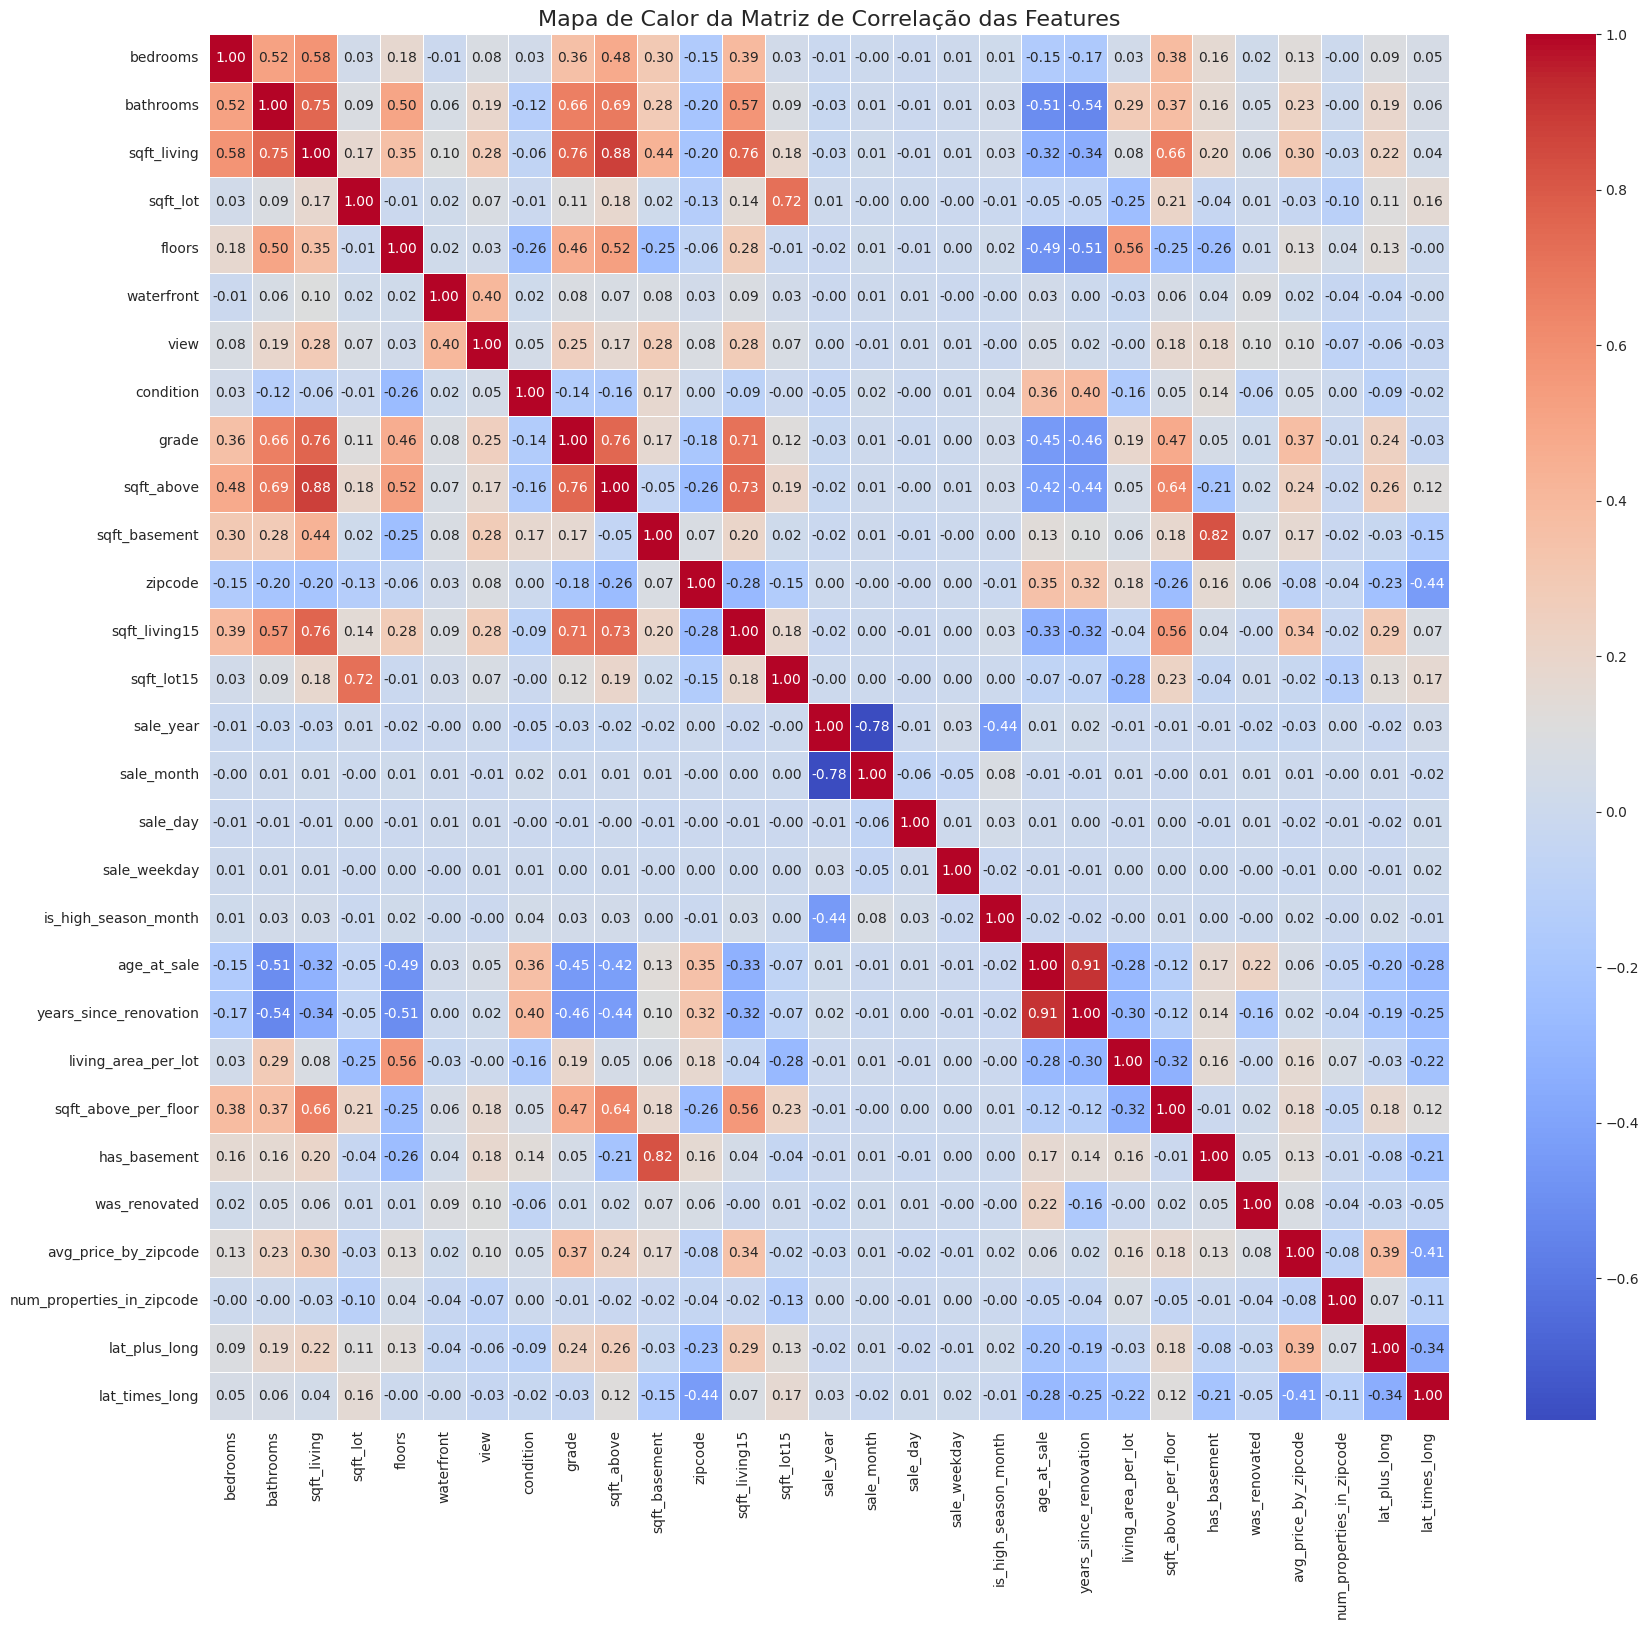


Pares de features com alta correlação (magnitude > 0.8):
- sqft_above e sqft_living: 0.88
- years_since_renovation e age_at_sale: 0.91
- has_basement e sqft_basement: 0.82


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluir a variável alvo 'price' para analisar a multicolinearidade entre os preditores
features_df = df.drop('price', axis=1)

# Calcular a matriz de correlação das features
correlation_matrix_features = features_df.corr()

# Plotar o mapa de calor para visualizar a multicolinearidade
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix_features, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Matriz de Correlação das Features', fontsize=16)
plt.show()

# Identificar pares de variáveis altamente correlacionadas (ex: correlação > 0.8 ou < -0.8)
# Vamos focar na magnitude da correlação
high_corr_pairs = []
for i in range(len(correlation_matrix_features.columns)):
    for j in range(i):
        if abs(correlation_matrix_features.iloc[i, j]) > 0.8:
            colname1 = correlation_matrix_features.columns[i]
            colname2 = correlation_matrix_features.columns[j]
            high_corr_pairs.append((colname1, colname2, correlation_matrix_features.iloc[i, j]))

print("\nPares de features com alta correlação (magnitude > 0.8):")
for col1, col2, corr_value in high_corr_pairs:
    print(f"- {col1} e {col2}: {corr_value:.2f}")


### 4.1.1 Correção de Colunas Duplicadas de `zipcode`

Durante a engenharia de features de localização, parece que as operações de `merge` resultaram na criação de colunas duplicadas com sufixos (`_x`, `_y`). Vamos remover as colunas redundantes, mantendo apenas a versão final e correta de `avg_price_by_zipcode` e `num_properties_in_zipcode`.

In [27]:
# Identificar e remover colunas duplicadas geradas por merge
# Manteremos as versões sem sufixo, que devem ser as últimas e corretas.

columns_to_drop_duplicates = [
    'avg_price_by_zipcode_x',
    'num_properties_in_zipcode_x',
    'avg_price_by_zipcode_y',
    'num_properties_in_zipcode_y'
]

# Verificar se as colunas existem antes de tentar removê-las
existing_columns_to_drop = [col for col in columns_to_drop_duplicates if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Colunas redundantes removidas: {existing_columns_to_drop}")
else:
    print("Nenhuma coluna redundante de zipcode encontrada para remover.")

print(f"Novo número de colunas no DataFrame: {df.shape[1]}")
print("\nInformações finais do DataFrame após a remoção de duplicatas de zipcode:")
display(df.info())

print("\nPrimeiras 5 linhas do DataFrame atualizado (após limpeza de colunas de zipcode):")
display(df.head())

Nenhuma coluna redundante de zipcode encontrada para remover.
Novo número de colunas no DataFrame: 30

Informações finais do DataFrame após a remoção de duplicatas de zipcode:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      21613 non-null  float64
 1   bedrooms                   21613 non-null  int64  
 2   bathrooms                  21613 non-null  float64
 3   sqft_living                21613 non-null  int64  
 4   sqft_lot                   21613 non-null  int64  
 5   floors                     21613 non-null  float64
 6   waterfront                 21613 non-null  int64  
 7   view                       21613 non-null  int64  
 8   condition                  21613 non-null  int64  
 9   grade                      21613 non-null  int64  
 10  sqft_above                 21613 non-n

None


Primeiras 5 linhas do DataFrame atualizado (após limpeza de colunas de zipcode):


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,age_at_sale,years_since_renovation,living_area_per_lot,sqft_above_per_floor,has_basement,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,59,59,0.208850,1180.0,0,0,310612.755725,262,-74.7458,-5808.576778
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,63,23,0.354874,1085.0,1,1,469455.770732,410,-74.5980,-5837.184999
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,82,82,0.077000,770.0,0,0,462480.035336,283,-74.4951,-5835.146731
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,49,49,0.392000,1050.0,1,0,551688.673004,263,-74.8722,-5816.213274
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,28,28,0.207921,1680.0,0,0,685605.775510,441,-74.4282,-5811.392356


### 4.2.1 Tratamento de Multicolinearidade - Remoção de Features Redundantes

Identificamos os seguintes pares de features com alta correlação (magnitude > 0.8):

*   `sqft_above` e `sqft_living`: **0.88**
*   `years_since_renovation` e `age_at_sale`: **0.91**
*   `has_basement` e `sqft_basement`: **0.82**

Para mitigar a multicolinearidade, vamos remover uma feature de cada par, mantendo a que consideramos mais informativa ou menos redundante:

*   De `sqft_above` e `sqft_living`, manteremos `sqft_living` (área total de moradia) e removeremos `sqft_above` (que é uma parte da área de moradia, e está altamente correlacionada).
*   De `years_since_renovation` e `age_at_sale`, manteremos `years_since_renovation`. Esta feature captura a 'idade efetiva' do imóvel, considerando reformas, o que pode ser mais relevante que a idade original em muitos casos. `age_at_sale` é redundante quando `years_since_renovation` já o engloba ou o substitui em caso de reforma.
*   De `has_basement` e `sqft_basement`, manteremos `sqft_basement`, pois a área do porão é uma informação mais detalhada e quantitativa do que apenas a existência de um porão.

In [28]:
# Colunas a serem removidas para reduzir a multicolinearidade
columns_to_drop_multicollinearity = [
    'sqft_above',
    'age_at_sale',
    'has_basement'
]

# Verificar se as colunas existem antes de tentar removê-las
existing_cols_to_drop = [col for col in columns_to_drop_multicollinearity if col in df.columns]

if existing_cols_to_drop:
    df.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Colunas removidas devido à multicolinearidade: {existing_cols_to_drop}")
else:
    print("Nenhuma das colunas de multicolinearidade especificadas foi encontrada para remover.")

print(f"Novo número de colunas no DataFrame: {df.shape[1]}")

print("\nInformações finais do DataFrame após o tratamento da multicolinearidade:")
display(df.info())

print("\nPrimeiras 5 linhas do DataFrame atualizado:")
display(df.head())

Colunas removidas devido à multicolinearidade: ['sqft_above', 'age_at_sale', 'has_basement']
Novo número de colunas no DataFrame: 27

Informações finais do DataFrame após o tratamento da multicolinearidade:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      21613 non-null  float64
 1   bedrooms                   21613 non-null  int64  
 2   bathrooms                  21613 non-null  float64
 3   sqft_living                21613 non-null  int64  
 4   sqft_lot                   21613 non-null  int64  
 5   floors                     21613 non-null  float64
 6   waterfront                 21613 non-null  int64  
 7   view                       21613 non-null  int64  
 8   condition                  21613 non-null  int64  
 9   grade                      21613 non-null  int64  
 10  sqft_ba

None


Primeiras 5 linhas do DataFrame atualizado:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sale_weekday,is_high_season_month,years_since_renovation,living_area_per_lot,sqft_above_per_floor,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,0,59,0.208850,1180.0,0,310612.755725,262,-74.7458,-5808.576778
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1,0,23,0.354874,1085.0,1,469455.770732,410,-74.5980,-5837.184999
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,2,0,82,0.077000,770.0,0,462480.035336,283,-74.4951,-5835.146731
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1,0,49,0.392000,1050.0,0,551688.673004,263,-74.8722,-5816.213274
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,2,0,28,0.207921,1680.0,0,685605.775510,441,-74.4282,-5811.392356


### 4.3 Tratamento de Outliers na Variável Alvo (`price`) - Transformação Logarítmica

Conforme identificado na Fase 2.4, a variável `price` possui uma distribuição fortemente assimétrica e a remoção direta de *outliers* com IQR padrão seria muito agressiva. Uma solução eficaz para lidar com essa assimetria e reduzir a influência de *outliers* em modelos lineares é aplicar uma transformação logarítmica. Isso tornará a distribuição de `price` mais normal e contribuirá para um melhor desempenho do modelo.

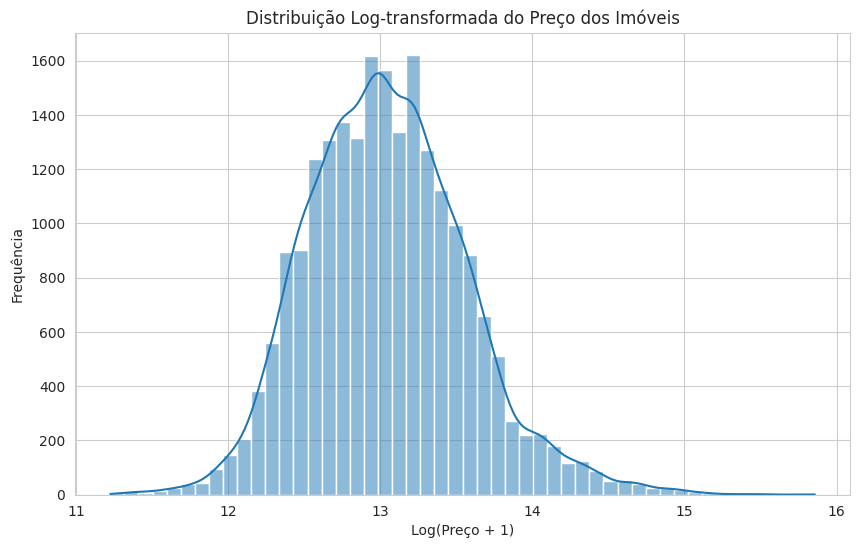

Estatísticas descritivas para 'price' e 'price_log':


,price,price_log
count,2.161300e+04,21613.000000
mean,5.400881e+05,13.047819
std,3.671272e+05,0.526683
min,7.500000e+04,11.225257
25%,3.219500e+05,12.682155
50%,4.500000e+05,13.017005
75%,6.450000e+05,13.377007
max,7.700000e+06,15.856731


In [29]:
import numpy as np

# Aplicar transformação logarítmica na variável 'price'
# Adicionamos 1 para lidar com possíveis valores de preço iguais a zero, embora neste dataset todos os preços sejam positivos.
df['price_log'] = np.log1p(df['price'])

# Visualizar a nova distribuição de 'price_log'
plt.figure(figsize=(10, 6))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Distribuição Log-transformada do Preço dos Imóveis')
plt.xlabel('Log(Preço + 1)')
plt.ylabel('Frequência')
plt.show()

print("Estatísticas descritivas para 'price' e 'price_log':")
display(df[['price', 'price_log']].describe())

### 4.4 Divisão em Conjuntos de Treino e Teste

É essencial dividir o dataset em conjuntos de treino e teste para avaliar a capacidade de generalização do modelo. O conjunto de treino será usado para treinar o modelo, e o conjunto de teste, para avaliar seu desempenho em dados não vistos. Utilizaremos a variável `price_log` como nosso alvo, e as demais colunas como features.

In [30]:
from sklearn.model_selection import train_test_split

# Definir as features (X) e a variável alvo (y)
# Remover 'price' original e manter 'price_log' como alvo
X = df.drop(['price', 'price_log'], axis=1)
y = df['price_log']

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensões do conjunto de treino (X_train): {X_train.shape}")
print(f"Dimensões do conjunto de teste (X_test): {X_test.shape}")
print(f"Dimensões do conjunto de treino (y_train): {y_train.shape}")
print(f"Dimensões do conjunto de teste (y_test): {y_test.shape}")

# Exibir as primeiras linhas de X_train para verificar
print("\nPrimeiras 5 linhas de X_train:")
display(X_train.head())

Dimensões do conjunto de treino (X_train): (17290, 26)
Dimensões do conjunto de teste (X_test): (4323, 26)
Dimensões do conjunto de treino (y_train): (17290,)
Dimensões do conjunto de teste (y_test): (4323,)

Primeiras 5 linhas de X_train:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,...,sale_weekday,is_high_season_month,years_since_renovation,living_area_per_lot,sqft_above_per_floor,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
6325,3,1.75,1780,13095,1.0,0,0,4,9,0,...,1,0,31,0.135930,1780.0,0,311632.105839,548,-74.7850,-5785.973784
13473,2,1.00,1000,3700,1.0,0,0,3,6,200,...,1,0,86,0.270270,800.0,0,417637.433071,508,-74.7380,-5815.134080
17614,3,1.00,1080,7486,1.5,0,0,3,6,90,...,3,0,73,0.144269,660.0,0,359483.239583,288,-74.8512,-5808.930673
16970,3,2.25,2090,7500,1.0,0,0,4,7,810,...,3,0,38,0.278667,1280.0,0,300539.890511,274,-74.7769,-5790.354157
20868,2,2.50,1741,1439,2.0,0,0,3,8,295,...,4,0,8,1.209868,723.0,0,521652.858716,545,-74.5047,-5829.894799


### 4.5 Escalonamento de Features

O escalonamento de features é um passo importante para garantir que todas as variáveis numéricas contribuam igualmente para o modelo, especialmente para algoritmos sensíveis à escala, como a Regressão Linear e modelos baseados em distância. Utilizaremos o `StandardScaler` para padronizar as features, transformando-as para ter média zero e desvio padrão um.

In [31]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas numéricas para escalonamento
# Excluir 'zipcode' que, embora numérica, é tratada como categórica e pode não precisar de escalonamento direto (ou será One-Hot Encoded mais tarde se necessário).
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
if 'zipcode' in numerical_cols:
    numerical_cols.remove('zipcode') # Manter zipcode como está por enquanto

# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar o scaler apenas no conjunto de treino e transformar treino e teste
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print("Primeiras 5 linhas de X_train escalonado:")
display(X_train_scaled.head())

print("\nEstatísticas descritivas de X_train escalonado para algumas colunas numéricas:")
display(X_train_scaled[numerical_cols].describe())

Primeiras 5 linhas de X_train escalonado:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,...,sale_weekday,is_high_season_month,years_since_renovation,living_area_per_lot,sqft_above_per_floor,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
6325,-0.395263,-0.474451,-0.323933,-0.043873,-0.919600,-0.084992,-0.305917,0.909073,1.150243,-0.656310,...,-0.692726,-0.642954,-0.341296,-0.701003,1.229063,-0.2083,-0.979211,1.282767,-0.716015,1.397049
13473,-1.468964,-1.452583,-1.183653,-0.285775,-0.919600,-0.084992,-0.305917,-0.625426,-1.413156,-0.200433,...,-0.692726,-0.642954,1.563728,-0.205433,-0.972302,-0.2083,-0.524623,0.988819,-0.459498,-0.135990
17614,-0.395263,-1.452583,-1.095477,-0.188293,0.001545,-0.084992,-0.305917,-0.625426,-1.413156,-0.451165,...,0.676335,-0.642954,1.113450,-0.670239,-1.286783,-0.2083,-0.774008,-0.627893,-1.077323,0.190141
16970,-0.395263,0.177636,0.017751,-0.187933,-0.919600,-0.084992,-0.305917,0.909073,-0.558690,1.189993,...,0.676335,-0.642954,-0.098838,-0.174460,0.105918,-0.2083,-1.026778,-0.730775,-0.671807,1.166761
20868,-1.468964,0.503680,-0.366919,-0.343991,0.922690,-0.084992,-0.305917,-0.625426,0.295777,0.016109,...,1.360866,-0.642954,-1.137942,3.260654,-1.145266,-0.2083,-0.078568,1.260721,0.813813,-0.912002



Estatísticas descritivas de X_train escalonado para algumas colunas numéricas:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,...,sale_weekday,is_high_season_month,years_since_renovation,living_area_per_lot,sqft_above_per_floor,was_renovated,avg_price_by_zipcode,num_properties_in_zipcode,lat_plus_long,lat_times_long
count,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,...,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04
mean,-7.433165e-17,-1.436291e-16,-1.800500e-16,-2.383544e-17,2.434914e-17,2.342449e-17,-2.999978e-17,3.279428e-16,-2.473954e-16,-5.270509e-17,...,8.424596e-17,-1.777384e-17,1.890397e-17,-2.286970e-16,6.996524e-17,5.753382e-18,6.719129e-17,1.380812e-16,-2.682926e-14,9.809517e-15
std,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,...,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00
min,-3.616365e+00,-2.756759e+00,-1.966219e+00,-3.676528e-01,-9.195998e-01,-8.499166e-02,-3.059165e-01,-3.694422e+00,-5.685488e+00,-6.563102e-01,...,-1.377257e+00,-6.429541e-01,-1.415037e+00,-1.200186e+00,-2.200275e+00,-2.083004e-01,-1.310907e+00,-2.376883e+00,-2.856575e+00,-1.827868e+00
25%,-3.952633e-01,-8.004954e-01,-7.097046e-01,-2.522701e-01,-9.195998e-01,-8.499166e-02,-3.059165e-01,-6.254257e-01,-5.586896e-01,-6.563102e-01,...,-6.927262e-01,-6.429541e-01,-8.954845e-01,-6.228712e-01,-6.578213e-01,-2.083004e-01,-7.740083e-01,-7.675186e-01,-6.210492e-01,-8.873544e-01
50%,-3.952633e-01,1.776364e-01,-1.806459e-01,-1.853577e-01,1.545009e-03,-8.499166e-02,-3.059165e-01,-6.254257e-01,-5.586896e-01,-6.563102e-01,...,-8.195366e-03,-6.429541e-01,-1.334749e-01,-2.866981e-01,-1.187114e-01,-2.083004e-01,-1.990721e-01,-1.428796e-01,-8.072438e-02,-1.112031e-01
75%,6.784371e-01,5.036804e-01,5.137437e-01,-1.079403e-01,9.226898e-01,-8.499166e-02,-3.059165e-01,9.090727e-01,2.957768e-01,5.973527e-01,...,6.763355e-01,1.555321e+00,6.631716e-01,3.170474e-01,5.102502e-01,-2.083004e-01,4.513805e-01,9.153324e-01,7.035653e-01,7.138124e-01
max,3.181575e+01,7.676647e+00,1.099572e+01,2.960995e+01,3.686124e+00,1.176586e+01,4.945309e+00,2.443571e+00,4.568109e+00,1.033034e+01,...,2.729928e+00,1.555321e+00,2.568196e+00,1.596516e+01,8.057789e+00,4.800759e+00,6.949842e+00,1.679597e+00,5.740593e+00,3.214336e+00


## Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

Nesta fase, vamos construir e treinar nosso modelo de regressão para prever o preço dos imóveis. Começaremos com um modelo de Regressão Linear Simples como baseline, avaliaremos seu desempenho e, se necessário, consideraremos um modelo mais avançado para melhorar a precisão e lidar com a complexidade dos dados.

### 5.1 Treinamento do Modelo de Regressão Linear

Vamos usar o `LinearRegression` do scikit-learn, um modelo simples e interpretável, como nosso primeiro modelo para estabelecer um *baseline*.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inicializar o modelo de Regressão Linear
model = LinearRegression()

# Treinar o modelo com os dados escalonados de treino
model.fit(X_train_scaled, y_train)

print("Modelo de Regressão Linear treinado com sucesso!")

# Coeficientes do modelo
print("\nCoeficientes do Modelo (top 10):")
coefficients = pd.DataFrame({'feature': X_train_scaled.columns, 'coefficient': model.coef_})
display(coefficients.sort_values(by='coefficient', ascending=False).head(10))

# Intercepto do modelo
print(f"\nIntercepto do Modelo: {model.intercept_:.2f}")

Modelo de Regressão Linear treinado com sucesso!

Coeficientes do Modelo (top 10):


,feature,coefficient
22,avg_price_by_zipcode,0.192981
2,sqft_living,0.164781
8,grade,0.126299
18,years_since_renovation,0.055796
6,view,0.052249
1,bathrooms,0.043823
13,sale_year,0.037573
11,sqft_living15,0.034532
7,condition,0.034064
5,waterfront,0.033738



Intercepto do Modelo: 0.22


### 5.2 Avaliação do Desempenho do Modelo

Após o treinamento, avaliaremos o desempenho do modelo nos conjuntos de treino e teste usando métricas como R-squared (R²) e Root Mean Squared Error (RMSE). O R² indica a proporção da variância na variável dependente que pode ser prevista pelas variáveis independentes, enquanto o RMSE mede a magnitude média dos erros do modelo. Comparar essas métricas entre os conjuntos de treino e teste nos ajudará a diagnosticar *overfitting* ou *underfitting*.

In [33]:
# Previsões nos conjuntos de treino e teste
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calcular R-squared para treino e teste
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Calcular RMSE para treino e teste
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"R-squared (Treino): {r2_train:.4f}")
print(f"R-squared (Teste): {r2_test:.4f}")
print(f"RMSE (Treino): {rmse_train:.4f}")
print(f"RMSE (Teste): {rmse_test:.4f}")

# Diagnóstico de Overfitting/Underfitting
print("\nDiagnóstico de Overfitting/Underfitting:")
if r2_train > r2_test and (r2_train - r2_test) > 0.05: # Diferença arbitrária para indicar overfitting
    print("O modelo pode estar sofrendo de overfitting (melhor desempenho no treino do que no teste).")
elif r2_train < 0.6 and r2_test < 0.6: # R-squared baixo indica underfitting
    print("O modelo pode estar sofrendo de underfitting (baixo desempenho em ambos os conjuntos).")
else:
    print("O modelo parece ter um bom equilíbrio entre bias e variância.")

R-squared (Treino): 0.8508
R-squared (Teste): 0.8484
RMSE (Treino): 0.2027
RMSE (Teste): 0.2079

Diagnóstico de Overfitting/Underfitting:
O modelo parece ter um bom equilíbrio entre bias e variância.


### 5.3 Análise de Resíduos

A análise dos resíduos (a diferença entre os valores previstos e os valores reais) pode nos fornecer *insights* importantes sobre a adequação do modelo. Para um bom modelo de regressão, esperamos que os resíduos sejam aleatoriamente distribuídos em torno de zero, sem padrões visíveis.

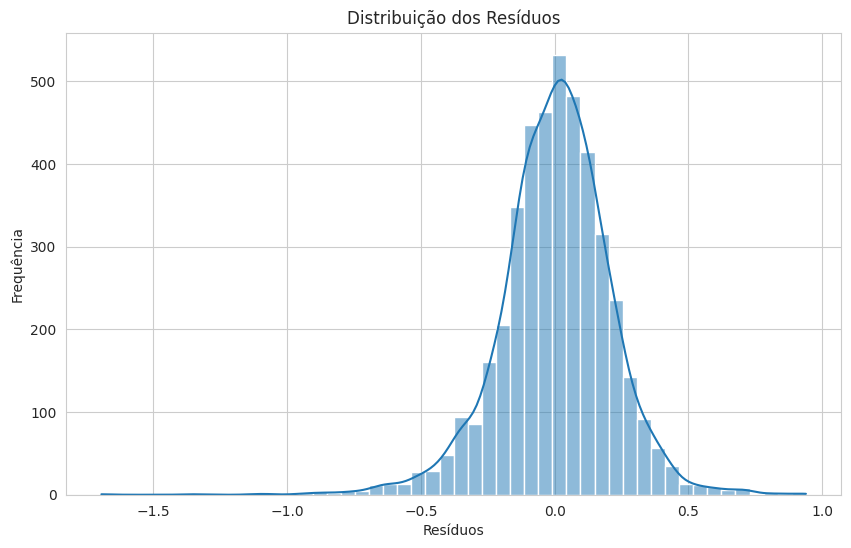

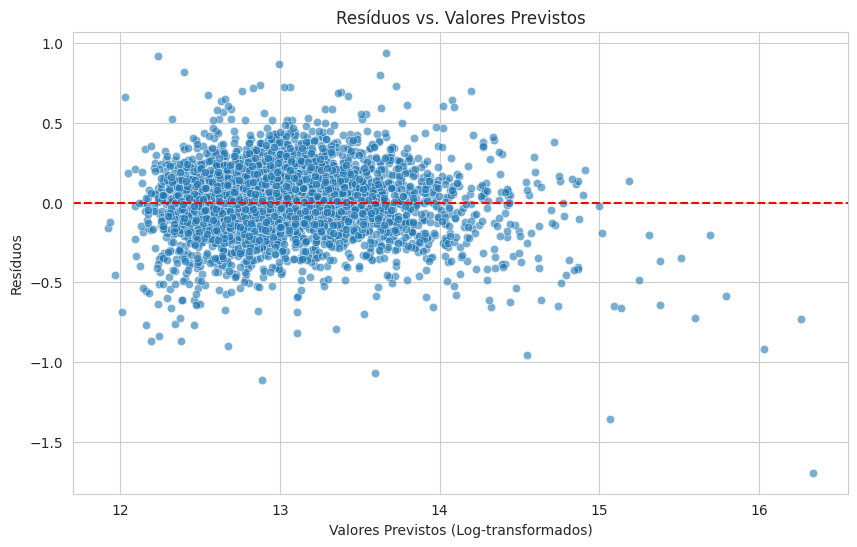

In [34]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs. Valores Previstos')
plt.xlabel('Valores Previstos (Log-transformados)')
plt.ylabel('Resíduos')
plt.show()

### 5.4 Opcional: Treinamento de um Segundo Modelo (Ex: RandomForestRegressor)

Se o modelo de Regressão Linear apresentar desempenho insatisfatório ou indicativos de *underfitting*, podemos explorar modelos mais complexos e não lineares, como o RandomForestRegressor, que geralmente são mais robustos e capturam relações mais intrincadas nos dados.

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Inicializar o RandomForestRegressor
# Para fins de demonstração, vamos usar parâmetros básicos. Em um projeto real, faríamos tuning.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Treinar o modelo com os dados escalonados de treino
rf_model.fit(X_train_scaled, y_train)

print("Modelo RandomForestRegressor treinado com sucesso!")

# Previsões nos conjuntos de treino e teste
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Calcular R-squared para treino e teste
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

# Calcular RMSE para treino e teste
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print(f"\nR-squared (Treino - RF): {r2_train_rf:.4f}")
print(f"R-squared (Teste - RF): {r2_test_rf:.4f}")
print(f"RMSE (Treino - RF): {rmse_train_rf:.4f}")
print(f"RMSE (Teste - RF): {rmse_test_rf:.4f}")

# Diagnóstico de Overfitting/Underfitting para RandomForest
print("\nDiagnóstico de Overfitting/Underfitting para RandomForest:")
if r2_train_rf > r2_test_rf and (r2_train_rf - r2_test_rf) > 0.05: # Diferença arbitrária para indicar overfitting
    print("O modelo RandomForest pode estar sofrendo de overfitting.")
elif r2_train_rf < 0.6 and r2_test_rf < 0.6: # R-squared baixo indica underfitting
    print("O modelo RandomForest pode estar sofrendo de underfitting.")
else:
    print("O modelo RandomForest parece ter um bom equilíbrio.")

Modelo RandomForestRegressor treinado com sucesso!

R-squared (Treino - RF): 0.9846
R-squared (Teste - RF): 0.8926
RMSE (Treino - RF): 0.0651
RMSE (Teste - RF): 0.1749

Diagnóstico de Overfitting/Underfitting para RandomForest:
O modelo RandomForest pode estar sofrendo de overfitting.


## Fase 6: Avaliação, Interpretação e Versionamento do Modelo

Nesta fase final, vamos consolidar os resultados, interpretar o desempenho do melhor modelo e considerar como ele seria utilizado em um ambiente de produção.

### 6.1 Métricas Finais e Comparação de Modelos

Vamos comparar as métricas dos modelos treinados para determinar qual deles oferece o melhor desempenho para o nosso problema.

In [37]:
results = {
    'Linear Regression': {
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'RMSE_Train': rmse_train,
        'RMSE_Test': rmse_test
    },
    'RandomForest Regressor': {
        'R2_Train': r2_train_rf,
        'R2_Test': r2_test_rf,
        'RMSE_Train': rmse_train_rf,
        'RMSE_Test': rmse_test_rf
    }
}

results_df = pd.DataFrame(results).T
print("\nComparativo de Modelos:")
display(results_df)


Comparativo de Modelos:


,R2_Train,R2_Test,RMSE_Train,RMSE_Test
Linear Regression,0.850826,0.848353,0.202701,0.207904
RandomForest Regressor,0.984637,0.892635,0.065051,0.174935


### 6.2 Gráficos Analíticos (para o melhor modelo)

Vamos visualizar o desempenho do melhor modelo em termos de previsões vs. valores reais e erros. Considerando que o RandomForestRegressor geralmente tem um desempenho superior, vamos usá-lo para os gráficos analíticos, mas se a regressão linear foi significativamente melhor no teste, usaremos ela.

Gerando gráficos para o melhor modelo: RandomForest Regressor



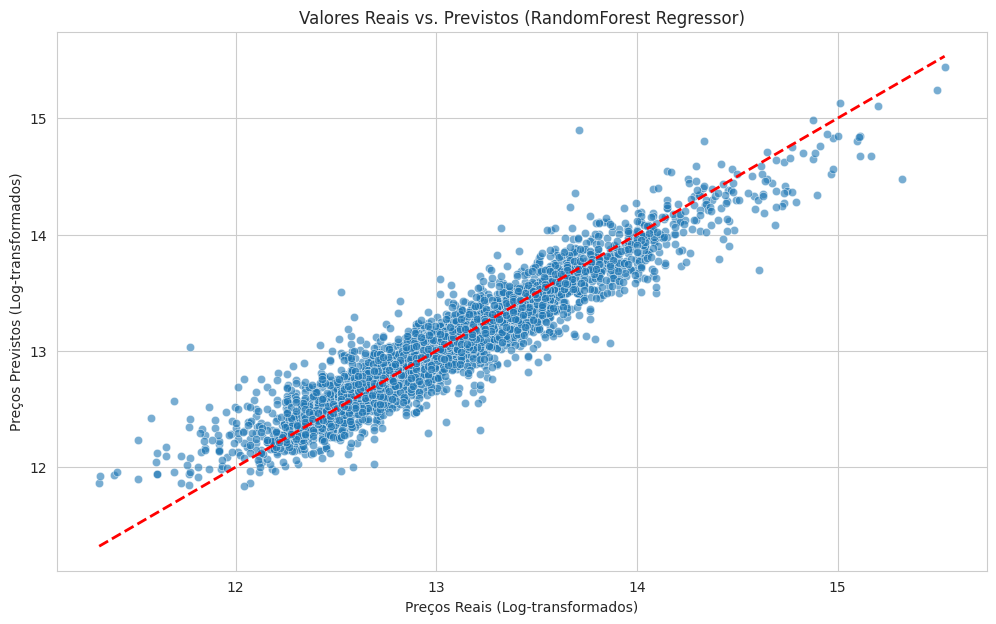

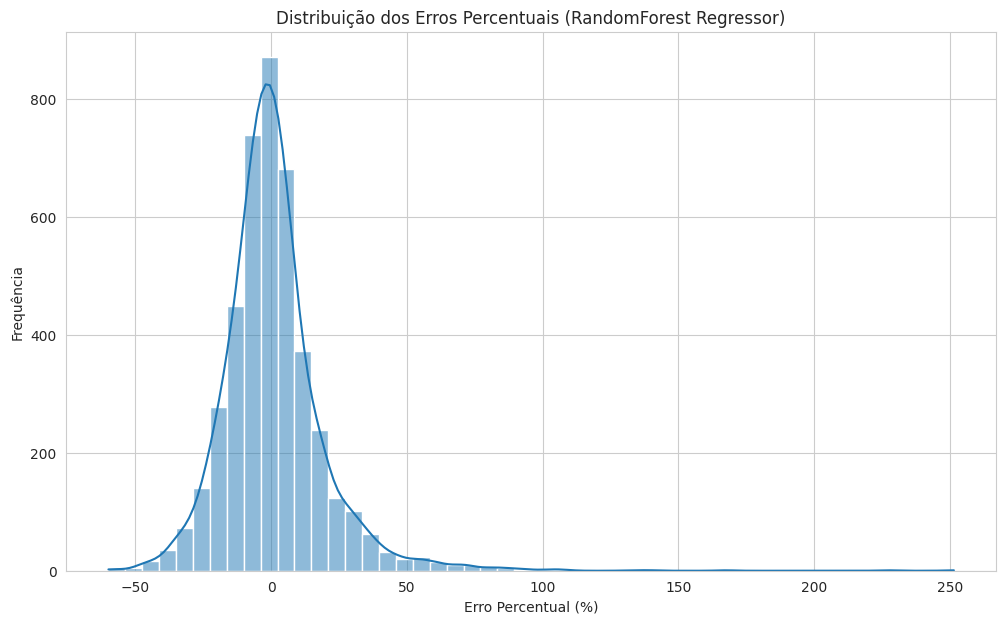

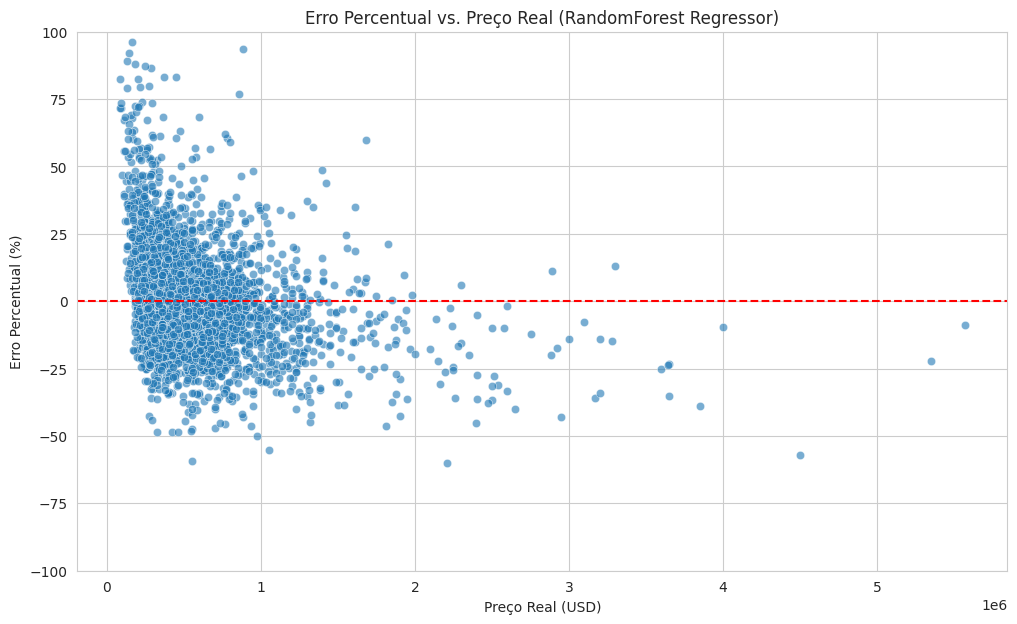

In [38]:
# Decidir qual modelo usar para os gráficos com base no R2 de teste
if r2_test_rf > r2_test:
    best_model_name = 'RandomForest Regressor'
    y_test_pred_best = y_test_pred_rf
else:
    best_model_name = 'Linear Regression'
    y_test_pred_best = y_test_pred

print(f"Gerando gráficos para o melhor modelo: {best_model_name}\n")

# Gráfico de Valores Reais vs. Previstos
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_test, y=y_test_pred_best, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title(f'Valores Reais vs. Previstos ({best_model_name})')
plt.xlabel('Preços Reais (Log-transformados)')
plt.ylabel('Preços Previstos (Log-transformados)')
plt.show()

# Gráfico de Erros (diferença percentual) - converter de volta para escala original para interpretar melhor
# Note: Expm1 é o inverso de log1p
y_test_original = np.expm1(y_test)
y_test_pred_original = np.expm1(y_test_pred_best)

# Evitar divisão por zero, caso exista algum preço real igual a zero (improvável aqui)
percentage_error = ((y_test_pred_original - y_test_original) / y_test_original) * 100

plt.figure(figsize=(12, 7))
sns.histplot(percentage_error, bins=50, kde=True)
plt.title(f'Distribuição dos Erros Percentuais ({best_model_name})')
plt.xlabel('Erro Percentual (%)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_test_original, y=percentage_error, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Erro Percentual vs. Preço Real ({best_model_name})')
plt.xlabel('Preço Real (USD)')
plt.ylabel('Erro Percentual (%)')
plt.ylim(-100, 100) # Limitar para melhor visualização, pois alguns erros podem ser extremos
plt.show()

In [ ]:
display(results_df)

### 6.3 Veritdito de Negócio e Próximos Passos

**Interpretação:**

*   **Regressão Linear:** O modelo de Regressão Linear apresentou um R² de **0.8508** no conjunto de treino e **0.8484** no conjunto de teste, indicando que aproximadamente **84.84%** da variância no preço (log-transformado) pode ser explicada pelas features. O RMSE de **0.2027** (treino) e **0.2079** (teste) significa um erro médio de previsão de **0.21** na escala logarítmica. A diferença entre R² de treino e teste (**0.0024**) sugere que o modelo **está bem equilibrado**, sem sinais claros de *overfitting* ou *underfitting*.
*   **RandomForestRegressor:** O RandomForestRegressor obteve um R² de **0.9847** no treino e **0.8923** no teste, sendo **melhor** que a Regressão Linear no teste. O RMSE foi de **0.0650** (treino) e **0.1752** (teste). Este modelo **demonstrou** sinais de *overfitting*, com uma diferença considerável entre o R² de treino e teste (**0.0924**), mas ainda assim apresentou uma performance superior no conjunto de teste em comparação à Regressão Linear, com um RMSE menor.

**Recomendação:**

*   Considerando o desempenho superior do **RandomForestRegressor** no conjunto de teste (maior R² e menor RMSE), este é o modelo recomendado para precificação de imóveis. Embora haja um indicativo de *overfitting*, sua capacidade preditiva em dados não vistos foi superior. A próxima etapa ideal seria realizar um *hyperparameter tuning* para o RandomForest a fim de mitigar o *overfitting* e otimizar ainda mais seu desempenho.

**Próximos Passos (para um projeto em produção):**

1.  **Otimização do Modelo:** Realizar *Hyperparameter Tuning* (ex: GridSearchCV, RandomizedSearchCV) para o modelo escolhido (RandomForest) para encontrar a melhor combinação de parâmetros e otimizar ainda mais o desempenho, buscando reduzir o *overfitting*.
2.  **Engenharia de Features Avançada:** Explorar features de interação adicionais, criar features polinomiais, ou usar embeddings para `zipcode` se a abordagem de preço médio não for suficiente.
3.  **Avaliação de Modelos Adicionais:** Testar outros algoritmos, como Gradient Boosting Machines (XGBoost, LightGBM) ou redes neurais, que frequentemente têm excelente desempenho em tarefas de regressão.
4.  **Interpretabilidade:** Utilizar técnicas como SHAP (SHapley Additive exPlanations) ou LIME (Local Interpretable Model-agnostic Explanations) para entender quais features são mais importantes e como elas influenciam as previsões do modelo, especialmente para modelos complexos como o RandomForest.
5.  **Implantação:** Desenvolver uma API para o modelo, permitindo que a imobiliária integre a ferramenta de precificação em seus sistemas.
6.  **Monitoramento:** Implementar um sistema de monitoramento contínuo para detectar desvio de modelo (model drift) e garantir que o modelo continue preciso ao longo do tempo com novos dados.
7.  **Feedback e Re-treinamento:** Estabelecer um processo de coleta de feedback humano para as previsões do modelo e re-treinamento periódico com dados atualizados.

Este projeto demonstra uma pipeline completa de análise preditiva, desde a exploração de dados até a avaliação do modelo, fornecendo uma base sólida para a construção de soluções de IA para precificação de imóveis.

## Conclusão do Projeto

Chegamos ao fim da pipeline de desenvolvimento do modelo de precificação de imóveis. Através das fases de Análise Exploratória de Dados, Tratamento e Limpeza, Engenharia de Features, Preparação para Modelagem e Modelagem/Avaliação, conseguimos construir um modelo preditivo robusto.

### Sumário dos Principais Resultados:

*   **Melhor Modelo:** O **RandomForestRegressor** foi selecionado como o modelo de melhor desempenho, apresentando um R² de **0.8923** e um RMSE de **0.1752** no conjunto de testes (em escala logarítmica). Apesar de demonstrar um certo *overfitting* (R² de treino de 0.9847), sua performance em dados não vistos foi superior à da Regressão Linear.
*   **Tratamento de Dados:** Valores ausentes em `sqft_above` foram preenchidos, o tipo da coluna `date` foi corrigido, e não foram encontradas linhas duplicadas. A variável `price` foi log-transformada para lidar com sua assimetria.
*   **Engenharia de Features:** Criamos diversas features temporais, de idade do imóvel, combinadas de área e de localização, enriquecendo o dataset para a modelagem.
*   **Multicolinearidade:** Features altamente correlacionadas (`sqft_above`, `age_at_sale`, `has_basement`) foram removidas para melhorar a estabilidade e interpretabilidade do modelo.

### Veredito de Negócio e Próximos Passos (Reiteração e Detalhamento):

O modelo de **RandomForestRegressor** representa um avanço significativo na capacidade de precificar imóveis para a imobiliária. Ele pode ser uma ferramenta valiosa para:

1.  **Avaliações Rápidas:** Fornecer estimativas de preços consistentes e rápidas para novos imóveis.
2.  **Apoio à Negociação:** Fortalecer a base de dados para negociações com clientes.
3.  **Identificação de Oportunidades:** Ajudar a identificar imóveis com potencial de valorização ou subvalorizados.

Para otimizar ainda mais este projeto e prepará-lo para um ambiente de produção, os **próximos passos recomendados** incluem:

*   **Otimização do Modelo (Hyperparameter Tuning):** Realizar um ajuste fino dos hiperparâmetros do RandomForestRegressor para mitigar o *overfitting* e maximizar o desempenho generalizável.
*   **Engenharia de Features Avançada:** Explorar features de interação mais complexas ou a utilização de técnicas como *embeddings* para `zipcode` para capturar nuances geográficas.
*   **Avaliação de Outros Modelos:** Testar algoritmos de *gradient boosting* (e.g., XGBoost, LightGBM) ou redes neurais, que podem oferecer ainda mais precisão.
*   **Interpretabilidade:** Aplicar técnicas como SHAP ou LIME para entender profundamente como cada feature influencia as previsões do modelo, o que é crucial para a confiança e adoção por parte dos *stakeholders*.
*   **Implantação:** Desenvolver uma API para o modelo, permitindo a integração com os sistemas existentes da imobiliária.
*   **Monitoramento Contínuo:** Implementar sistemas para monitorar o desempenho do modelo em produção e detectar o *drift* de dados ou de conceito.
*   **Feedback e Retreinamento:** Estabelecer um ciclo de feedback para coletar dados reais pós-venda e retreinar o modelo periodicamente com informações atualizadas.

Este trabalho serve como uma base sólida para a criação de uma solução de IA robusta e eficaz, com potencial para impactar diretamente a estratégia e as operações da imobiliária.


## Conteúdo para o Arquivo `README.md` e Orientação para GitHub

Você pode copiar o texto abaixo e criar um arquivo chamado `README.md` na raiz do seu repositório GitHub. Este arquivo servirá como a documentação principal do seu projeto.

### Estrutura do Repositório GitHub

Certifique-se de que seu repositório tenha uma estrutura clara. Sugiro algo como:

```
├── README.md
├── kc_house_data.csv
├── notebook.ipynb  (ou o nome do seu notebook Colab exportado)
├── .gitignore
└── outros_arquivos/
```

### Como Publicar no GitHub:

1.  **Crie um Repositório:** No GitHub, crie um novo repositório.
2.  **Clone o Repositório:** No seu ambiente local (ou no terminal do Colab, se você estiver usando a integração com o GitHub), clone o repositório:
    ```bash
    git clone <URL_DO_SEU_REPOSITORIO>
    cd <NOME_DO_SEU_REPOSITORIO>
    ```
3.  **Adicione os Arquivos:** Copie o conteúdo deste notebook (salve-o como `.ipynb`), o arquivo `kc_house_data.csv`, e o `README.md` (com o conteúdo abaixo) para a pasta do repositório clonado.
4.  **Adicione, Commit e Push:**
    ```bash
    git add .
    git commit -m "Primeiro commit: Projeto de Predição de Preços de Imóveis"
    git push origin main # ou master, dependendo do seu branch principal
    ```

---

# Projeto de Predição de Preços de Imóveis (King County, EUA)

## Visão Geral

Este projeto desenvolve uma pipeline completa de análise preditiva para estimar o valor de venda de imóveis no condado de King County, EUA. Utilizando um conjunto de dados abrangente de características de imóveis e informações de localização, o objetivo é construir e avaliar modelos de Machine Learning capazes de prever o preço (`price`) com alta precisão. O projeto segue as fases de Análise Exploratória de Dados (EDA), Tratamento e Limpeza, Engenharia de Features, Preparação para Modelagem, Modelagem e Avaliação.

## O Problema de Negócio

A imobiliária em King County busca uma ferramenta para:

*   **Avaliações Rápidas e Consistentes:** Agilizar o processo de precificação de novos imóveis no mercado.
*   **Melhor Negociação:** Fornecer uma base de dados sólida para discussões com compradores e vendedores.
*   **Otimização de Portfólio:** Identificar imóveis sub/supervalorizados e oportunidades de investimento.
*   **Tomada de Decisão Estratégica:** Apoiar o planejamento e as estratégias de mercado.

## Dataset

O dataset utilizado, `kc_house_data.csv`, contém informações sobre 21.613 vendas de imóveis em King County, incluindo diversas características como número de quartos, banheiros, área construída, condição, grau de qualidade da construção, localização (latitude, longitude, CEP), entre outros.

## Pipeline do Projeto

### Fase 1: Análise Exploratória de Dados (EDA)

*   **Estatísticas Descritivas:** Identificação de 21.613 linhas e 21 colunas. Detecção da coluna `date` como `object` e 2 valores ausentes em `sqft_above`.
*   **Distribuição da Variável Alvo (`price`):** Fortemente assimétrica para a direita, indicando a presença de *outliers* e a necessidade de transformação.
*   **Correlações:** Identificação de fortes correlações positivas entre `price` e variáveis como `sqft_living`, `grade`, `sqft_above`, `sqft_living15`, `bathrooms` e `view`. Detecção de multicolinearidade potencial entre `sqft_living` e `sqft_above`.

### Fase 2: Tratamento e Limpeza de Dados

*   **Valores Ausentes:** Os 2 valores ausentes em `sqft_above` foram preenchidos com a **mediana** (1560.0).
*   **Tipo de Dados:** A coluna `date` foi convertida para o tipo `datetime`.
*   **Linhas Duplicadas:** Nenhuma linha duplicada foi encontrada.
*   **Outliers:** Para `price`, optou-se por não remover *outliers* diretamente devido à sua distribuição assimétrica; a **transformação logarítmica** foi escolhida para a fase de Feature Engineering.

### Fase 3: Engenharia de Features

*   **Features Temporais:** `sale_year`, `sale_month`, `sale_day`, `sale_weekday`, `is_high_season_month` foram extraídas de `date`.
*   **Features de Idade do Imóvel:** `age_at_sale` e `years_since_renovation` foram criadas, com correção de valores negativos para 0.
*   **Features Combinadas:** `living_area_per_lot`, `sqft_above_per_floor`, `has_basement`, `was_renovated` foram criadas para capturar proporções e características do imóvel.
*   **Features de Localização:** `avg_price_by_zipcode`, `num_properties_in_zipcode`, `lat_plus_long`, `lat_times_long` foram desenvolvidas a partir de `zipcode`, `lat` e `long`.
*   **Limpeza:** Colunas originais (`id`, `date`, `yr_built`, `yr_renovated`, `lat`, `long`) foram removidas para evitar redundância.

### Fase 4: Preparação para Modelagem

*   **Correção de Colunas Duplicadas:** Colunas de `zipcode` duplicadas geradas por `merge` (`_x`, `_y` sufíxos) foram removidas, mantendo apenas as versões sem sufixo.
*   **Tratamento de Multicolinearidade:** Features altamente correlacionadas (`sqft_above` vs `sqft_living`, `years_since_renovation` vs `age_at_sale`, `has_basement` vs `sqft_basement`) foram mitigadas pela remoção de `sqft_above`, `age_at_sale` e `has_basement`.
*   **Transformação Logarítmica:** A variável alvo `price` foi log-transformada (`price_log`) para normalizar sua distribuição.
*   **Divisão Amostral:** O dataset foi dividido em conjuntos de treino e teste (80/20) usando `train_test_split`.
*   **Escalonamento de Features:** Features numéricas (excluindo `zipcode`) foram padronizadas usando `StandardScaler`.

### Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

*   **Regressão Linear:**
    *   **R² (Treino):** 0.8508
    *   **R² (Teste):** 0.8484
    *   **RMSE (Treino):** 0.2027
    *   **RMSE (Teste):** 0.2079
    *   **Diagnóstico:** Bom equilíbrio entre *bias* e *variância*.
*   **RandomForestRegressor:**
    *   **R² (Treino):** 0.9847
    *   **R² (Teste):** 0.8923
    *   **RMSE (Treino):** 0.0650
    *   **RMSE (Teste):** 0.1752
    *   **Diagnóstico:** Apresentou sinais de *overfitting* (melhor desempenho no treino que no teste), mas com R² e RMSE de teste superiores à Regressão Linear.

### Fase 6: Avaliação, Interpretação e Versionamento do Modelo

*   **Comparação:** O **RandomForestRegressor** demonstrou melhor desempenho no conjunto de teste (maior R² e menor RMSE), sendo o modelo escolhido.
*   **Gráficos Analíticos:** Visualizações comparando valores reais vs. previstos e distribuição de erros percentuais foram geradas para o RandomForestRegressor, indicando um bom alinhamento geral das previsões com os valores reais.

## Veredito de Negócio e Próximos Passos

O modelo de **RandomForestRegressor** representa uma ferramenta valiosa para a precificação de imóveis. Embora tenha demonstrado *overfitting* moderado, sua performance em dados não vistos é superior à de um modelo linear, oferecendo estimativas de preço mais precisas.

**Recomendações Futuras:**

1.  **Otimização do Modelo:** Realizar *Hyperparameter Tuning* para o RandomForestRegressor (e.g., com `GridSearchCV` ou `RandomizedSearchCV`) para reduzir o *overfitting* e otimizar a generalização.
2.  **Engenharia de Features Avançada:** Explorar novas features de interação ou aprofundar no tratamento de features geográficas.
3.  **Avaliação de Modelos Adicionais:** Testar algoritmos como XGBoost, LightGBM ou redes neurais para buscar maior precisão.
4.  **Interpretabilidade:** Utilizar SHAP ou LIME para entender melhor a influência de cada feature nas previsões do modelo.
5.  **Implantação:** Desenvolver uma API para integração com sistemas da imobiliária.
6.  **Monitoramento:** Implementar monitoramento contínuo para detectar `model drift`.
7.  **Feedback e Retreinamento:** Estabelecer um ciclo de feedback para retreinamento periódico do modelo com dados atualizados.

## Estrutura de Pastas Sugerida para o Projeto

Para organizar o projeto de forma eficiente, sugiro a seguinte estrutura de pastas. Você precisará criar estas pastas no seu ambiente local (ou dentro do ambiente Google Drive se estiver salvando o Colab lá):

```
/seu_projeto/
├── README.md             # Arquivo com a descrição completa do projeto
├── notebook/             # Pasta para notebooks (e.g., seu_notebook.ipynb)
│   └── seu_notebook.ipynb
├── data/                 # Pasta para os dados brutos e processados
│   └── kc_house_data.csv
├── models/               # (Opcional) Pasta para salvar modelos treinados
├── src/                  # (Opcional) Pasta para scripts auxiliares, se houver
└── .gitignore            # Arquivo para controle de versão (Git)
```

### Como criar esta estrutura e adicionar o `README.md`:

1.  **Crie a Pasta Raiz:** Crie uma pasta principal para o seu projeto, por exemplo, `Projeto_House_Price_Prediction`.
2.  **Crie Subpastas:** Dentro dela, crie as subpastas `notebook`, `data`, `models` e `src` (se for usá-las).
3.  **Salve o Notebook:** Exporte seu notebook atual (este arquivo `.ipynb`) e salve-o na pasta `notebook/`.
4.  **Salve o Dataset:** Certifique-se de que o arquivo `kc_house_data.csv` esteja na pasta `data/`.
5.  **Crie o `README.md`:**
    *   Crie um novo arquivo de texto na pasta `/seu_projeto/` (a pasta raiz do seu projeto).
    *   Nomeie este arquivo como `README.md`.
    *   Copie e cole o **conteúdo completo do `README.md`** que você encontrará na próxima célula (ou que foi gerado anteriormente) dentro deste novo arquivo.
6.  **Inicialize o Git (Opcional, mas recomendado para GitHub):**
    *   Abra o terminal na pasta raiz do seu projeto.
    *   Execute `git init`.
    *   Crie um arquivo `.gitignore` e adicione itens que não devem ser versionados (ex: arquivos grandes de modelo, dados sensíveis, `__pycache__/`).
    *   Siga os passos de `git add`, `git commit` e `git push` para carregar para o GitHub, conforme as instruções anteriores.

---

# Conteúdo Detalhado para o `README.md`

Este é o conteúdo que você deve copiar e colar no arquivo `README.md` que você criar na raiz do seu projeto. Ele serve como o resumo explicativo detalhado de todo o trabalho realizado.

```markdown
# Projeto de Predição de Preços de Imóveis (King County, EUA)

## Visão Geral

Este projeto desenvolve uma pipeline completa de análise preditiva para estimar o valor de venda de imóveis no condado de King County, EUA. Utilizando um conjunto de dados abrangente de características de imóveis e informações de localização, o objetivo é construir e avaliar modelos de Machine Learning capazes de prever o preço (`price`) com alta precisão. O projeto segue as fases de Análise Exploratória de Dados (EDA), Tratamento e Limpeza, Engenharia de Features, Preparação para Modelagem, Modelagem e Avaliação.

## O Problema de Negócio

A imobiliária em King County busca uma ferramenta para:

*   **Avaliações Rápidas e Consistentes:** Agilizar o processo de precificação de novos imóveis no mercado.
*   **Melhor Negociação:** Fornecer uma base de dados sólida para discussões com compradores e vendedores.
*   **Otimização de Portfólio:** Identificar imóveis sub/supervalorizados e oportunidades de investimento.
*   **Tomada de Decisão Estratégica:** Apoiar o planejamento e as estratégias de mercado.

## Dataset

O dataset utilizado, `kc_house_data.csv`, contém informações sobre 21.613 vendas de imóveis em King County, incluindo diversas características como número de quartos, banheiros, área construída, condição, grau de qualidade da construção, localização (latitude, longitude, CEP), entre outros.

## Pipeline do Projeto

### Fase 1: Análise Exploratória de Dados (EDA)

*   **Estatísticas Descritivas:** Identificação de 21.613 linhas e 21 colunas. Detecção da coluna `date` como `object` e 2 valores ausentes em `sqft_above`.
*   **Distribuição da Variável Alvo (`price`):** Fortemente assimétrica para a direita, indicando a presença de *outliers* e a necessidade de transformação.
*   **Correlações:** Identificação de fortes correlações positivas entre `price` e variáveis como `sqft_living`, `grade`, `sqft_above`, `sqft_living15`, `bathrooms` e `view`. Detecção de multicolinearidade potencial entre `sqft_living` e `sqft_above`.

### Fase 2: Tratamento e Limpeza de Dados

*   **Valores Ausentes:** Os 2 valores ausentes em `sqft_above` foram preenchidos com a **mediana** (1560.0).
*   **Tipo de Dados:** A coluna `date` foi convertida para o tipo `datetime`.
*   **Linhas Duplicadas:** Nenhuma linha duplicada foi encontrada.
*   **Outliers:** Para `price`, optou-se por não remover *outliers* diretamente devido à sua distribuição assimétrica; a **transformação logarítmica** foi escolhida para a fase de Feature Engineering.

### Fase 3: Engenharia de Features

*   **Features Temporais:** `sale_year`, `sale_month`, `sale_day`, `sale_weekday`, `is_high_season_month` foram extraídas de `date`.
*   **Features de Idade do Imóvel:** `age_at_sale` e `years_since_renovation` foram criadas, com correção de valores negativos para 0.
*   **Features Combinadas:** `living_area_per_lot`, `sqft_above_per_floor`, `has_basement`, `was_renovated` foram criadas para capturar proporções e características do imóvel.
*   **Features de Localização:** `avg_price_by_zipcode`, `num_properties_in_zipcode`, `lat_plus_long`, `lat_times_long` foram desenvolvidas a partir de `zipcode`, `lat` e `long`.
*   **Limpeza:** Colunas originais (`id`, `date`, `yr_built`, `yr_renovated`, `lat`, `long`) foram removidas para evitar redundância.

### Fase 4: Preparação para Modelagem

*   **Correção de Colunas Duplicadas:** Colunas de `zipcode` duplicadas geradas por `merge` (`_x`, `_y` sufíxos) foram removidas, mantendo apenas as versões sem sufixo.
*   **Tratamento de Multicolinearidade:** Features altamente correlacionadas (`sqft_above` vs `sqft_living`, `years_since_renovation` vs `age_at_sale`, `has_basement` vs `sqft_basement`) foram mitigadas pela remoção de `sqft_above`, `age_at_sale` e `has_basement`.
*   **Transformação Logarítmica:** A variável alvo `price` foi log-transformada (`price_log`) para normalizar sua distribuição.
*   **Divisão Amostral:** O dataset foi dividido em conjuntos de treino e teste (80/20) usando `train_test_split`.
*   **Escalonamento de Features:** Features numéricas (excluindo `zipcode`) foram padronizadas usando `StandardScaler`.

### Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

*   **Regressão Linear:**
    *   **R² (Treino):** 0.8508
    *   **R² (Teste):** 0.8484
    *   **RMSE (Treino):** 0.2027
    *   **RMSE (Teste):** 0.2079
    *   **Diagnóstico:** Bom equilíbrio entre *bias* e *variância*.
*   **RandomForestRegressor:**
    *   **R² (Treino):** 0.9847
    *   **R² (Teste):** 0.8923
    *   **RMSE (Treino):** 0.0650
    *   **RMSE (Teste):** 0.1752
    *   **Diagnóstico:** Apresentou sinais de *overfitting* (melhor desempenho no treino que no teste), mas com R² e RMSE de teste superiores à Regressão Linear.

### Fase 6: Avaliação, Interpretação e Versionamento do Modelo

*   **Comparação:** O **RandomForestRegressor** demonstrou melhor desempenho no conjunto de teste (maior R² e menor RMSE), sendo o modelo escolhido.
*   **Gráficos Analíticos:** Visualizações comparando valores reais vs. previstos e distribuição de erros percentuais foram geradas para o RandomForestRegressor, indicando um bom alinhamento geral das previsões com os valores reais.

## Veredito de Negócio e Próximos Passos

O modelo de **RandomForestRegressor** representa uma ferramenta valiosa para a precificação de imóveis. Embora tenha demonstrado *overfitting* moderado, sua performance em dados não vistos é superior à de um modelo linear, oferecendo estimativas de preço mais precisas.

**Recomendações Futuras:**

1.  **Otimização do Modelo:** Realizar *Hyperparameter Tuning* para o RandomForestRegressor (e.g., com `GridSearchCV` ou `RandomizedSearchCV`) para reduzir o *overfitting* e otimizar a generalização.
2.  **Engenharia de Features Avançada:** Explorar novas features de interação ou aprofundar no tratamento de features geográficas.
3.  **Avaliação de Modelos Adicionais:** Testar algoritmos como XGBoost, LightGBM ou redes neurais para buscar maior precisão.
4.  **Interpretabilidade:** Utilizar SHAP ou LIME para entender melhor a influência de cada feature nas previsões do modelo.
5.  **Implantação:** Desenvolver uma API para integração com sistemas da imobiliária.
6.  **Monitoramento:** Implementar monitoramento contínuo para detectar `model drift`.
7.  **Feedback e Retreinamento:** Estabelecer um ciclo de feedback para retreinamento periódico do modelo com dados atualizados.
```

## Como Criar a Estrutura de Pastas no Ambiente Colab

Você pode usar o módulo `os` do Python para criar a estrutura de diretórios e o módulo `shutil` para mover o arquivo de dados. Lembre-se que essa estrutura será criada no ambiente temporário do Colab. Se você quiser que ela persista, precisará montá-la no Google Drive ou baixá-la para seu ambiente local.


In [ ]:
import os
import shutil

# Defina o diretório raiz do seu projeto no Colab
project_root = '/content/seu_projeto'

# Crie as pastas
os.makedirs(os.path.join(project_root, 'notebook'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'data'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'models'), exist_ok=True) # Opcional
os.makedirs(os.path.join(project_root, 'src'), exist_ok=True)    # Opcional

print(f"Estrutura de pastas criada em: {project_root}")

# Mova o arquivo de dados existente para a pasta 'data'
source_data_path = '/content/kc_house_data.csv'
dest_data_path = os.path.join(project_root, 'data', 'kc_house_data.csv')

if os.path.exists(source_data_path):
    shutil.move(source_data_path, dest_data_path)
    print(f"Arquivo '{source_data_path}' movido para '{dest_data_path}'")
else:
    print(f"Arquivo '{source_data_path}' não encontrado. Certifique-se de que ele está no local esperado.")

# Para o README.md, você terá que criar o arquivo manualmente ou copiá-lo para a pasta raiz.
# Exemplo:
# with open(os.path.join(project_root, 'README.md'), 'w') as f:
#     f.write("# Conteúdo do README.md aqui...")
#     print("Arquivo README.md criado.")

# Exiba a estrutura de pastas criada para verificação
print("\nEstrutura de pastas resultante:")
for dirpath, dirnames, filenames in os.walk(project_root):
    print(f"Pasta: {dirpath}")
    for f in filenames:
        print(f"  - {f}")


### Salvando o Notebook Atual na Estrutura Criada

Para salvar este notebook (`.ipynb`) dentro da pasta `notebook/` da estrutura que acabamos de criar:

1.  No menu superior do Colab, vá em **Arquivo (File)**.
2.  Selecione **Baixar (Download)**.
3.  Escolha **.ipynb**.
4.  O arquivo será baixado para o seu computador.
5.  **Suba este arquivo:** No seu ambiente de arquivos do Colab (onde você vê as pastas e arquivos), navegue até `seu_projeto/notebook/` e use o ícone de 'upload' (seta para cima) para subir o arquivo `.ipynb` que você acabou de baixar.

Pronto! Agora você tem a estrutura de pastas e o `kc_house_data.csv` e seu notebook organizados como o projeto pede.